# NB11 - PW_CinePartition0 native flow-wave audit

## Purpose

This notebook independently reproduces and audits native PW flow-wave extraction from raw Mindray TE7 `PW_CinePartition0.bin` bytes.

The main question is:

Can a candidate native PW flow-wave be reproduced from raw bytes, and is it useful as an experimental timing/pulsatility signal?

## Scope

### In scope

- Reproduce the fixed-page structure of `PW_CinePartition0.bin` from raw bytes.
- Verify which record slots are live dynamic records.
- Test whether records `0..13` plausibly form 7 consecutive `(I, Q)` sample pairs per page.
- Verify the actual native-derived timebase from byte counts and reconstructed sample spacing.
- Reproduce the candidate wall-filtered flow-wave from raw bytes if the structure supports it.
- Compare native flow-wave heart-rate estimates against project-owned AVI/audio timing references.
- Test whether native phase/frequency/Kasai-style measures recover calibrated AVI-derived velocity evidence.
- Document sample-rate, labeling, implementation, and interpretation boundaries.

### Out of scope

- No clinical interpretation.
- No native PSV, EDV, RI, PI, VTI, SV, CO, or BP.
- No claim of calibrated native velocity.
- No claim that a flow-wave is a native velocity envelope.
- No claim that a spectrogram-like visualization is a decoded display spectrogram.
- No broad AVI velocity extraction work.

## Interpretation Boundary

All findings in this notebook are experimental unless independently reproduced from raw project data.

Use careful labels:

- candidate
- experimental
- timing-like
- pulsatility-like
- spectrogram-like
- metadata-like
- control-like
- not validated
- consistent with

This notebook may support a native timing or pulsatility signal. It does not validate calibrated velocity or clinical measurements.

Do not use terms like decoded, confirmed, ground truth, clinical, or native velocity measurement unless the evidence supports them.

## Imports & Setup


In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sg

# NB11 - PW_CinePartition0 native flow-wave audit

SAVE_OUTPUTS = False
PAGE_SIZE_BYTES = 1296
HEADER_BYTES = 16
RECORD_BYTES = 8
RECORDS_PER_PAGE = (PAGE_SIZE_BYTES - HEADER_BYTES) // RECORD_BYTES

PAGE_RATE_HZ = 500.0
LIVE_RECORD_CANDIDATE_COUNT = 16
IQ_RECORD_CANDIDATE_COUNT = 14
IQ_PAIRS_PER_PAGE = 7
CANDIDATE_IQ_RATE_HZ = PAGE_RATE_HZ * IQ_PAIRS_PER_PAGE

PHASE_BINS_CANDIDATE = 39

In [2]:
def resolve_project_root(candidate_roots=None):
    """
    Resolve the DopplerLab project root.

    This function checks known project locations and returns the first path
    containing expected DopplerLab project folders or files. It does not create
    or modify files.
    """
    if candidate_roots is None:
        candidate_roots = [
            Path(r"E:\DopplerLab"),
            Path(r"D:\code\DopplerLab"),
            Path.cwd(),
            Path.cwd().parent,
        ]

    checked = []

    for root in candidate_roots:
        root = Path(root)
        checked.append(str(root))

        if not root.exists():
            continue

        expected_any = [
            root / "ultrasound_recordings",
            root / "feature_exports",
            root / "reports",
            root / "AGENTS.md",
        ]

        if any(path.exists() for path in expected_any):
            return root

    raise FileNotFoundError(
        "Could not resolve DopplerLab project root. Checked:\n"
        + "\n".join(checked)
    )


def build_nb11_paths(project_root):
    """
    Build paths for NB11 native PW flow-wave audit.

    This only defines project-owned input and optional output paths.
    It does not create directories.
    """
    project_root = Path(project_root)
    nb04_v2_dir = project_root / "feature_exports" / "nb04_v2_batch_2026_06_13"

    paths = {
        "PROJECT_ROOT": project_root,
        "NATIVE_BATCH_DIR": project_root / "ultrasound_recordings" / "batch_2026_06_13_native",

        "NATIVE_TO_NB04_MAPPING": project_root / "reports" / "native_to_nb04_manual_match_template.csv",
        "NATIVE_PAIR_RANGE_HR_SUMMARY": project_root / "reports" / "native_pair_range_hr_summary.csv",

        "NB04_V2_DIR": nb04_v2_dir,
        "NB04_V2_FRAME_LEVEL_VELOCITY": nb04_v2_dir / "nb04_v2_frame_level_velocity_features.csv",
        "NB04_V2_ACCEPTED_REGISTRY": nb04_v2_dir / "nb04_v2_accepted_recording_registry.csv",

        "NB11_REPORTS_DIR": project_root / "reports" / "nb11_pw_flow_wave_audit",
        "NB11_FIGURES_DIR": project_root / "figures" / "nb11_pw_flow_wave_audit",
        "NB11_DOCS_DIR": project_root / "docs" / "nb11_pw_flow_wave_audit",
    }

    return paths


def build_path_status_table(paths):
    """
    Build a path status table for NB11 inputs and optional outputs.
    """
    required_inputs = {
        "PROJECT_ROOT",
        "NATIVE_BATCH_DIR",
        "NATIVE_TO_NB04_MAPPING",
        "NATIVE_PAIR_RANGE_HR_SUMMARY",
        "NB04_V2_FRAME_LEVEL_VELOCITY",
        "NB04_V2_ACCEPTED_REGISTRY",
    }

    rows = []

    for key, path in paths.items():
        path = Path(path)

        if key in required_inputs:
            role = "required_project_input"
        else:
            role = "optional_output_location"

        rows.append({
            "key": key,
            "role": role,
            "exists": path.exists(),
            "path": str(path),
        })

    return pd.DataFrame(rows)


def find_pw_native_files(native_batch_dir):
    """Find native PW_CinePartition0.bin files under the native recording batch."""
    return sorted(Path(native_batch_dir).rglob("PW_CinePartition0.bin"))


def recording_id_from_pw_path(path):
    """Infer the recording identifier from a PW_CinePartition0.bin path."""
    path = Path(path)

    if path.parent.name.lower() == "native":
        return path.parent.parent.name

    return path.parent.name


def print_nb11_setup_summary(project_root, paths, path_status_df, pw_files):
    """Print a compact NB11 setup summary."""
    print("NB11 setup summary")
    print("==================")
    print(f"PROJECT_ROOT: {project_root}")
    print(f"NATIVE_BATCH_DIR: {paths['NATIVE_BATCH_DIR']}")
    print(f"NB04_V2_DIR: {paths['NB04_V2_DIR']}")
    print()
    print(f"PW_CinePartition0.bin files found: {len(pw_files)}")

    if pw_files:
        recording_ids = [recording_id_from_pw_path(path) for path in pw_files]
        print("First recordings:")
        for recording_id in recording_ids[:5]:
            print(f"  - {recording_id}")

    missing_required = path_status_df[
        (path_status_df["role"] == "required_project_input")
        & (~path_status_df["exists"])
    ]

    print()
    if len(missing_required):
        print("Missing required project inputs:")
        print(missing_required[["key", "path"]].to_string(index=False))
    else:
        print("Required project inputs are available.")

    print()
    print("Saving outputs enabled:", SAVE_OUTPUTS)

In [3]:
PROJECT_ROOT = resolve_project_root()
PATHS = build_nb11_paths(PROJECT_ROOT)

path_status_df = build_path_status_table(PATHS)
pw_files = find_pw_native_files(PATHS["NATIVE_BATCH_DIR"])

print_nb11_setup_summary(
    project_root=PROJECT_ROOT,
    paths=PATHS,
    path_status_df=path_status_df,
    pw_files=pw_files,
)

path_status_df

NB11 setup summary
PROJECT_ROOT: E:\DopplerLab
NATIVE_BATCH_DIR: E:\DopplerLab\ultrasound_recordings\batch_2026_06_13_native
NB04_V2_DIR: E:\DopplerLab\feature_exports\nb04_v2_batch_2026_06_13

PW_CinePartition0.bin files found: 10
First recordings:
  - 202606130411060002SMP
  - 202606130413540003SMP
  - 202606130417060004SMP
  - 202606130420260005SMP
  - 202606130422440006SMP

Required project inputs are available.

Saving outputs enabled: False


,key,role,exists,path
0,PROJECT_ROOT,required_project_input,True,E:\DopplerLab
1,NATIVE_BATCH_DIR,required_project_input,True,E:\DopplerLab\ultrasound_recordings\batch_2026...
2,NATIVE_TO_NB04_MAPPING,required_project_input,True,E:\DopplerLab\reports\native_to_nb04_manual_ma...
3,NATIVE_PAIR_RANGE_HR_SUMMARY,required_project_input,True,E:\DopplerLab\reports\native_pair_range_hr_sum...
4,NB04_V2_DIR,optional_output_location,True,E:\DopplerLab\feature_exports\nb04_v2_batch_20...
5,NB04_V2_FRAME_LEVEL_VELOCITY,required_project_input,True,E:\DopplerLab\feature_exports\nb04_v2_batch_20...
6,NB04_V2_ACCEPTED_REGISTRY,required_project_input,True,E:\DopplerLab\feature_exports\nb04_v2_batch_20...
7,NB11_REPORTS_DIR,optional_output_location,False,E:\DopplerLab\reports\nb11_pw_flow_wave_audit
8,NB11_FIGURES_DIR,optional_output_location,False,E:\DopplerLab\figures\nb11_pw_flow_wave_audit
9,NB11_DOCS_DIR,optional_output_location,False,E:\DopplerLab\docs\nb11_pw_flow_wave_audit


## Raw PW page container audit

### What this tests

This experiment tests whether each `PW_CinePartition0.bin` file decomposes into complete fixed-size pages.

It also checks whether the 16-byte page header contains a zero-based monotonic counter across pages.

### Why this matters

The candidate native flow-wave depends on the assumption that `PW_CinePartition0.bin` is a fixed-page stream with `PAGE_SIZE_BYTES = 1296` and `PAGE_RATE_HZ = 500`.

If the page count, remainder bytes, or header counter are inconsistent, later I/Q reconstruction and timebase tests would need to stop or be revised.

In [4]:
def inspect_pw_page_container(pw_files):
    """
    Inspect fixed-page structure and header counters for PW_CinePartition0.bin files.

    This function reads only page headers after memory-mapping each file. It does not
    modify files and does not inspect record payload semantics.
    """
    required_names = [
        "PAGE_SIZE_BYTES",
        "HEADER_BYTES",
        "RECORD_BYTES",
        "RECORDS_PER_PAGE",
        "PAGE_RATE_HZ",
    ]
    missing = [name for name in required_names if name not in globals()]
    if missing:
        raise NameError(f"Missing setup variables: {missing}")

    rows = []

    for path in pw_files:
        path = Path(path)
        file_size = path.stat().st_size
        n_pages = file_size // PAGE_SIZE_BYTES
        remainder_bytes = file_size % PAGE_SIZE_BYTES

        row = {
            "recording": recording_id_from_pw_path(path),
            "file_size_bytes": int(file_size),
            "n_pages": int(n_pages),
            "remainder_bytes": int(remainder_bytes),
            "duration_s_at_500hz": float(n_pages / PAGE_RATE_HZ),
            "expected_payload_bytes_per_page": int(HEADER_BYTES + RECORDS_PER_PAGE * RECORD_BYTES),
            "counter_like_header_fields": "",
        }

        if n_pages == 0:
            rows.append(row)
            continue

        pages = np.memmap(
            path,
            dtype=np.uint8,
            mode="r",
            shape=(n_pages, PAGE_SIZE_BYTES),
        )

        header_bytes = np.asarray(pages[:, :HEADER_BYTES])
        header_u32 = (
            np.ascontiguousarray(header_bytes)
            .reshape(-1, 4)
            .view("<u4")
            .reshape(n_pages, 4)
        )

        counter_like_fields = []

        for field_index in range(4):
            values = header_u32[:, field_index].astype(np.uint64)

            if n_pages > 1:
                diffs = np.diff(values.astype(np.int64))
                diff1_fraction = float((diffs == 1).mean())
                n_bad_diffs = int((diffs != 1).sum())
            else:
                diff1_fraction = np.nan
                n_bad_diffs = 0

            row[f"h{field_index}_first"] = int(values[0])
            row[f"h{field_index}_last"] = int(values[-1])
            row[f"h{field_index}_n_unique"] = int(np.unique(values).size)
            row[f"h{field_index}_diff1_fraction"] = diff1_fraction
            row[f"h{field_index}_bad_diff_count"] = n_bad_diffs

            is_zero_based_counter = (
                int(values[0]) == 0
                and int(values[-1]) == n_pages - 1
                and n_bad_diffs == 0
            )

            if is_zero_based_counter:
                counter_like_fields.append(f"h{field_index}")

        row["counter_like_header_fields"] = ",".join(counter_like_fields)
        rows.append(row)

    return pd.DataFrame(rows)


In [5]:
container_df = inspect_pw_page_container(pw_files)

print("PW page container constants")
print("===========================")
print(f"PAGE_SIZE_BYTES: {PAGE_SIZE_BYTES}")
print(f"HEADER_BYTES: {HEADER_BYTES}")
print(f"RECORD_BYTES: {RECORD_BYTES}")
print(f"RECORDS_PER_PAGE: {RECORDS_PER_PAGE}")
print(f"HEADER_BYTES + RECORDS_PER_PAGE * RECORD_BYTES: {HEADER_BYTES + RECORDS_PER_PAGE * RECORD_BYTES}")
print(f"PAGE_RATE_HZ: {PAGE_RATE_HZ}")
print()

print("Container audit summary")
print("=======================")
print(f"Files inspected: {len(container_df)}")
print(f"Files with nonzero remainder: {int((container_df['remainder_bytes'] != 0).sum())}")
print(f"Files with a zero-based counter-like header field: {int((container_df['counter_like_header_fields'] != '').sum())}")

display_columns = [
    "recording",
    "file_size_bytes",
    "n_pages",
    "remainder_bytes",
    "duration_s_at_500hz",
    "counter_like_header_fields",
    "h0_first", "h0_last", "h0_n_unique",
    "h1_first", "h1_last", "h1_n_unique",
    "h2_first", "h2_last", "h2_n_unique",
    "h3_first", "h3_last", "h3_n_unique",
]

container_df[display_columns]

PW page container constants
PAGE_SIZE_BYTES: 1296
HEADER_BYTES: 16
RECORD_BYTES: 8
RECORDS_PER_PAGE: 160
HEADER_BYTES + RECORDS_PER_PAGE * RECORD_BYTES: 1296
PAGE_RATE_HZ: 500.0

Container audit summary
Files inspected: 10
Files with nonzero remainder: 0
Files with a zero-based counter-like header field: 0


,recording,file_size_bytes,n_pages,remainder_bytes,duration_s_at_500hz,counter_like_header_fields,h0_first,h0_last,h0_n_unique,h1_first,h1_last,h1_n_unique,h2_first,h2_last,h2_n_unique,h3_first,h3_last,h3_n_unique
0,202606130411060002SMP,38381040,29615,0,59.230,,4,4,1,294854,413310,29615,1888796160,1888796160,1,7,8,2
1,202606130413540003SMP,30444336,23491,0,46.982,,8,8,1,631080,725040,23491,1888796160,1888796160,1,7,7,2
2,202606130417060004SMP,27516672,21232,0,42.464,,12,12,1,1013186,1098110,21232,1888796160,1888796160,1,7,7,2
3,202606130420260005SMP,29502144,22764,0,45.528,,14,14,1,1414814,1505865,22764,1888796160,1888796160,1,7,7,2
4,202606130422440006SMP,33211296,25626,0,51.252,,16,16,1,1690366,1792866,25626,1888796160,1888796160,1,7,7,2
5,202606130426500007SMP,23776416,18346,0,36.692,,22,22,1,2182582,2255962,18346,1888796160,1888796160,1,7,7,2
6,202606130430380008SMP,28753056,22186,0,44.372,,28,28,1,2637853,2726593,22186,1888796160,1888796160,1,8,7,2
7,202606130433280009SMP,20557152,15862,0,31.724,,30,30,1,2979714,3043157,15862,1888796160,1888796160,1,7,7,2
8,202606130434130010SMP,21923136,16916,0,33.832,,32,32,1,3068131,3135791,16916,1888796160,1888796160,1,7,7,2
9,202606130437480012SMP,29176848,22513,0,45.026,,36,36,1,3499408,3589456,22513,512,512,1,7,7,2


### Raw PW page container audit interpretation

**Result classification:** supported with header-counter correction.

Evidence-supported observations:

- All 10 `PW_CinePartition0.bin` files decompose exactly into `1296` byte pages.
- No file has remainder bytes.
- `HEADER_BYTES + RECORDS_PER_PAGE * RECORD_BYTES = 1296`, consistent with a 16-byte header plus 160 8-byte records.
- `n_pages / 500` gives plausible recording durations for all files.
- No header field is a zero-based counter.
- Header field `h1` has one unique value per page in every recording and appears monotonic, but it does not start at zero.


## PW header timing-counter audit

### What this tests

This section tests whether the second 32-bit header field behaves like a monotonic timing or page counter.

The previous section found no zero-based page counter, but `h1` had one unique value per page in every recording.

### Why this matters

A monotonic header counter strengthens the fixed-page stream interpretation, even if the counter is scanner-local rather than zero-based.


In [6]:
def inspect_pw_header_counter_behavior(pw_files):
    """
    Inspect detailed behavior of 32-bit PW page header fields.

    This function focuses on monotonicity, stride, and unique values. It does
    not inspect record payload semantics.
    """
    rows = []

    for path in pw_files:
        path = Path(path)
        file_size = path.stat().st_size
        n_pages = file_size // PAGE_SIZE_BYTES

        pages = np.memmap(
            path,
            dtype=np.uint8,
            mode="r",
            shape=(n_pages, PAGE_SIZE_BYTES),
        )

        header_bytes = np.asarray(pages[:, :HEADER_BYTES])
        header_u32 = (
            np.ascontiguousarray(header_bytes)
            .reshape(-1, 4)
            .view("<u4")
            .reshape(n_pages, 4)
        )

        row = {
            "recording": recording_id_from_pw_path(path),
            "n_pages": int(n_pages),
        }

        for field_index in range(4):
            values = header_u32[:, field_index].astype(np.int64)

            if len(values) > 1:
                diffs = np.diff(values)
                diff_counts = Counter(diffs.tolist())
                most_common_diff, most_common_count = diff_counts.most_common(1)[0]
                monotonic_non_decreasing = bool(np.all(diffs >= 0))
                strictly_increasing = bool(np.all(diffs > 0))
                constant_stride = bool(len(diff_counts) == 1)
                bad_stride_count = int(len(diffs) - most_common_count)
            else:
                most_common_diff = np.nan
                most_common_count = 0
                monotonic_non_decreasing = True
                strictly_increasing = True
                constant_stride = True
                bad_stride_count = 0

            row[f"h{field_index}_first"] = int(values[0])
            row[f"h{field_index}_last"] = int(values[-1])
            row[f"h{field_index}_n_unique"] = int(np.unique(values).size)
            row[f"h{field_index}_most_common_diff"] = most_common_diff
            row[f"h{field_index}_bad_stride_count"] = bad_stride_count
            row[f"h{field_index}_constant_stride"] = constant_stride
            row[f"h{field_index}_monotonic_non_decreasing"] = monotonic_non_decreasing
            row[f"h{field_index}_strictly_increasing"] = strictly_increasing

        rows.append(row)

    return pd.DataFrame(rows)


header_counter_df = inspect_pw_header_counter_behavior(pw_files)

display_columns = [
    "recording",
    "n_pages",
    "h1_first",
    "h1_last",
    "h1_n_unique",
    "h1_most_common_diff",
    "h1_bad_stride_count",
    "h1_constant_stride",
    "h1_strictly_increasing",
    "h0_first",
    "h0_n_unique",
    "h2_first",
    "h2_n_unique",
    "h3_first",
    "h3_last",
    "h3_n_unique",
]

header_counter_df[display_columns]

,recording,n_pages,h1_first,h1_last,h1_n_unique,h1_most_common_diff,h1_bad_stride_count,h1_constant_stride,h1_strictly_increasing,h0_first,h0_n_unique,h2_first,h2_n_unique,h3_first,h3_last,h3_n_unique
0,202606130411060002SMP,29615,294854,413310,29615,4,15540,False,True,4,1,1888796160,1,7,8,2
1,202606130413540003SMP,23491,631080,725040,23491,4,6668,False,True,8,1,1888796160,1,7,7,2
2,202606130417060004SMP,21232,1013186,1098110,21232,4,9938,False,True,12,1,1888796160,1,7,7,2
3,202606130420260005SMP,22764,1414814,1505865,22764,3,13884,False,True,14,1,1888796160,1,7,7,2
4,202606130422440006SMP,25626,1690366,1792866,25626,4,9086,False,True,16,1,1888796160,1,7,7,2
5,202606130426500007SMP,18346,2182582,2255962,18346,3,11709,False,True,22,1,1888796160,1,7,7,2
6,202606130430380008SMP,22186,2637853,2726593,22186,4,5036,False,True,28,1,1888796160,1,8,7,2
7,202606130433280009SMP,15862,2979714,3043157,15862,3,8661,False,True,30,1,1888796160,1,7,7,2
8,202606130434130010SMP,16916,3068131,3135791,16916,4,8880,False,True,32,1,1888796160,1,7,7,2
9,202606130437480012SMP,22513,3499408,3589456,22513,4,5112,False,True,36,1,512,1,7,7,2


### PW header timing-counter audit interpretation

**Result classification:** partially supported with corrected wording.

Evidence-supported observations:

- Header field `h1` is strictly increasing in all 10 recordings.
- Header field `h1` has one unique value per page in all 10 recordings.
- Header field `h1` is not zero-based.
- Header field `h1` is not constant-stride.
- The most common increment is usually `3` or `4`, but many pages use different increments.
- Header fields `h0` and `h2` are stable within each recording.
- Header field `h3` has only two values within each recording.


## Live dynamic record census

### What this tests

This section tests which of the 160 8-byte record slots vary over time inside each PW page.

The working hypothesis is that records `0..15` are live dynamic records and records `16..159` are static or padding-like, with possible control/status-like exceptions.

### Why this matters

The candidate flow-wave reconstruction depends on the live-record boundary. If dynamic value content exists outside records `0..15`, the I/Q-pairing model would need to be revised.


In [7]:
def load_pw_record_views(path):
    """
    Load PW record bytes and typed field views for one PW_CinePartition0.bin file.

    The returned arrays expose all 160 records per page. This function reads the
    file as fixed 1296-byte pages and does not modify files.
    """
    path = Path(path)
    file_size = path.stat().st_size
    n_pages = file_size // PAGE_SIZE_BYTES
    remainder_bytes = file_size % PAGE_SIZE_BYTES

    if remainder_bytes != 0:
        raise ValueError(f"File is not an exact page multiple: {path}")

    pages = np.memmap(
        path,
        dtype=np.uint8,
        mode="r",
        shape=(n_pages, PAGE_SIZE_BYTES),
    )

    records_u8 = np.asarray(
        pages[:, HEADER_BYTES:].reshape(n_pages, RECORDS_PER_PAGE, RECORD_BYTES)
    )

    lo_bytes = np.ascontiguousarray(records_u8[:, :, 0:4]).reshape(-1, 4)
    hi_bytes = np.ascontiguousarray(records_u8[:, :, 4:8]).reshape(-1, 4)

    lo_i32 = lo_bytes.view("<i4").reshape(n_pages, RECORDS_PER_PAGE)
    hi_i32 = hi_bytes.view("<i4").reshape(n_pages, RECORDS_PER_PAGE)
    lo_f32 = lo_bytes.view("<f4").reshape(n_pages, RECORDS_PER_PAGE)
    hi_f32 = hi_bytes.view("<f4").reshape(n_pages, RECORDS_PER_PAGE)

    return {
        "n_pages": n_pages,
        "records_u8": records_u8,
        "lo_i32": lo_i32,
        "hi_i32": hi_i32,
        "lo_f32": lo_f32,
        "hi_f32": hi_f32,
    }


def safe_float_summary(values):
    """
    Summarize a float array without warning on all-NaN slices.
    """
    values = np.asarray(values)
    finite = np.isfinite(values)

    if not finite.any():
        return {
            "finite_fraction": float(finite.mean()),
            "min": np.nan,
            "max": np.nan,
            "std": np.nan,
        }

    finite_values = values[finite]

    return {
        "finite_fraction": float(finite.mean()),
        "min": float(finite_values.min()),
        "max": float(finite_values.max()),
        "std": float(finite_values.std()),
    }


def summarize_record_variability_for_file(path):
    """
    Summarize per-record variability for one PW file.

    This separates raw byte variability from typed field variability.
    It avoids treating control/status-like byte changes as live PW value records.
    """
    views = load_pw_record_views(path)
    records_u8 = views["records_u8"]
    n_pages = views["n_pages"]

    rows = []

    for record_index in range(RECORDS_PER_PAGE):
        rec_u8 = records_u8[:, record_index, :]

        lo_u8 = rec_u8[:, 0:4]
        hi_u8 = rec_u8[:, 4:8]

        raw_dynamic = bool(any(np.unique(rec_u8[:, byte_index]).size > 1 for byte_index in range(RECORD_BYTES)))
        lo_dynamic = bool(any(np.unique(lo_u8[:, byte_index]).size > 1 for byte_index in range(4)))
        hi_dynamic = bool(any(np.unique(hi_u8[:, byte_index]).size > 1 for byte_index in range(4)))

        if n_pages > 1:
            raw_change_fraction = float((rec_u8[1:] != rec_u8[:-1]).any(axis=1).mean())
            lo_change_fraction = float((lo_u8[1:] != lo_u8[:-1]).any(axis=1).mean())
            hi_change_fraction = float((hi_u8[1:] != hi_u8[:-1]).any(axis=1).mean())
        else:
            raw_change_fraction = 0.0
            lo_change_fraction = 0.0
            hi_change_fraction = 0.0

        lo_i32 = views["lo_i32"][:, record_index]
        hi_i32 = views["hi_i32"][:, record_index]
        hi_f32 = views["hi_f32"][:, record_index]

        hi_summary = safe_float_summary(hi_f32)

        rows.append({
            "recording": recording_id_from_pw_path(path),
            "record_index": record_index,
            "n_pages": int(n_pages),

            "raw_dynamic": raw_dynamic,
            "lo_dynamic": lo_dynamic,
            "hi_dynamic": hi_dynamic,

            "raw_change_fraction": raw_change_fraction,
            "lo_change_fraction": lo_change_fraction,
            "hi_change_fraction": hi_change_fraction,

            "lo_i32_n_unique": int(np.unique(lo_i32).size),
            "hi_i32_n_unique": int(np.unique(hi_i32).size),

            "hi_f32_finite_fraction": hi_summary["finite_fraction"],
            "hi_f32_min": hi_summary["min"],
            "hi_f32_max": hi_summary["max"],
            "hi_f32_std": hi_summary["std"],
        })

    return pd.DataFrame(rows)


def summarize_live_record_census(pw_files):
    """
    Summarize record-slot behavior across all PW files.

    Live value candidates are records whose second 4-byte field behaves like a
    finite dynamic float32 value in every recording.
    """
    per_record_tables = []

    for path in pw_files:
        per_record_tables.append(summarize_record_variability_for_file(path))

    record_variability_df = pd.concat(per_record_tables, ignore_index=True)

    batch_rows = []

    for record_index, group in record_variability_df.groupby("record_index"):
        dynamic_recordings = int(group["raw_dynamic"].sum())
        hi_dynamic_recordings = int(group["hi_dynamic"].sum())
        lo_dynamic_recordings = int(group["lo_dynamic"].sum())

        min_finite_fraction = float(group["hi_f32_finite_fraction"].min())
        median_hi_std = float(group["hi_f32_std"].median(skipna=True))
        max_hi_std = float(group["hi_f32_std"].max(skipna=True))

        live_value_candidate = (
            hi_dynamic_recordings == len(pw_files)
            and min_finite_fraction == 1.0
            and median_hi_std > 0.01
        )

        control_like_candidate = (
            dynamic_recordings > 0
            and not live_value_candidate
        )

        if live_value_candidate:
            record_class = "live_value_candidate"
        elif control_like_candidate:
            record_class = "control_like_candidate"
        else:
            record_class = "static_or_padding"

        batch_rows.append({
            "record_index": int(record_index),
            "record_class": record_class,
            "dynamic_recordings": dynamic_recordings,
            "lo_dynamic_recordings": lo_dynamic_recordings,
            "hi_dynamic_recordings": hi_dynamic_recordings,
            "all_recordings_raw_dynamic": bool(dynamic_recordings == len(pw_files)),
            "all_recordings_hi_dynamic": bool(hi_dynamic_recordings == len(pw_files)),
            "mean_raw_change_fraction": float(group["raw_change_fraction"].mean()),
            "mean_lo_change_fraction": float(group["lo_change_fraction"].mean()),
            "mean_hi_change_fraction": float(group["hi_change_fraction"].mean()),
            "median_hi_f32_std": median_hi_std,
            "max_hi_f32_std": max_hi_std,
            "min_hi_f32_finite_fraction": min_finite_fraction,
        })

    batch_census_df = pd.DataFrame(batch_rows)

    return record_variability_df, batch_census_df

In [8]:
record_variability_df, batch_census_df = summarize_live_record_census(pw_files)

live_value_slots = batch_census_df.loc[
    batch_census_df["record_class"] == "live_value_candidate",
    "record_index",
].tolist()

control_like_slots = batch_census_df.loc[
    batch_census_df["record_class"] == "control_like_candidate",
    "record_index",
].tolist()

print("Live dynamic record census summary")
print("==================================")
print(f"Records per page: {RECORDS_PER_PAGE}")
print(f"Files inspected: {len(pw_files)}")
print(f"Live value candidate slots: {live_value_slots}")
print(f"Control/status-like candidate slots: {control_like_slots}")
print()

print("First 24 record slots")
print("=====================")
display(batch_census_df.head(24))

print("Control/status-like candidate slots")
print("===================================")
display(batch_census_df[batch_census_df["record_class"] == "control_like_candidate"])

print("Last 16 record slots")
print("====================")
display(batch_census_df.tail(16))

Live dynamic record census summary
Records per page: 160
Files inspected: 10
Live value candidate slots: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Control/status-like candidate slots: [144, 154]

First 24 record slots


,record_index,record_class,dynamic_recordings,lo_dynamic_recordings,hi_dynamic_recordings,all_recordings_raw_dynamic,all_recordings_hi_dynamic,mean_raw_change_fraction,mean_lo_change_fraction,mean_hi_change_fraction,median_hi_f32_std,max_hi_f32_std,min_hi_f32_finite_fraction
0,0,live_value_candidate,10,10,10,True,True,0.999062,0.973951,0.999062,3.425257e+00,3.959378e+00,1.0
1,1,live_value_candidate,10,10,10,True,True,0.999050,0.974705,0.999050,3.258700e+00,3.919276e+00,1.0
2,2,live_value_candidate,10,10,10,True,True,0.999083,0.974288,0.999083,3.425125e+00,3.959340e+00,1.0
3,3,live_value_candidate,10,10,10,True,True,0.999147,0.974778,0.999147,3.258758e+00,3.919214e+00,1.0
4,4,live_value_candidate,10,10,10,True,True,0.999044,0.973695,0.999044,3.424966e+00,3.959397e+00,1.0
5,5,live_value_candidate,10,10,10,True,True,0.999180,0.974085,0.999180,3.258630e+00,3.919353e+00,1.0
6,6,live_value_candidate,10,10,10,True,True,0.999097,0.974200,0.999097,3.424789e+00,3.959630e+00,1.0
7,7,live_value_candidate,10,10,10,True,True,0.999017,0.974443,0.999017,3.258677e+00,3.920001e+00,1.0
8,8,live_value_candidate,10,10,10,True,True,0.998943,0.973736,0.998943,3.424724e+00,3.959702e+00,1.0
9,9,live_value_candidate,10,10,10,True,True,0.999083,0.974006,0.999083,3.258818e+00,3.919955e+00,1.0


Control/status-like candidate slots


,record_index,record_class,dynamic_recordings,lo_dynamic_recordings,hi_dynamic_recordings,all_recordings_raw_dynamic,all_recordings_hi_dynamic,mean_raw_change_fraction,mean_lo_change_fraction,mean_hi_change_fraction,median_hi_f32_std,max_hi_f32_std,min_hi_f32_finite_fraction
144,144,control_like_candidate,3,3,3,False,False,0.000027,0.000027,0.000027,0.0,0.0,1.0
154,154,control_like_candidate,10,10,0,True,False,0.039799,0.039799,0.000000,0.0,0.0,1.0


Last 16 record slots


,record_index,record_class,dynamic_recordings,lo_dynamic_recordings,hi_dynamic_recordings,all_recordings_raw_dynamic,all_recordings_hi_dynamic,mean_raw_change_fraction,mean_lo_change_fraction,mean_hi_change_fraction,median_hi_f32_std,max_hi_f32_std,min_hi_f32_finite_fraction
144,144,control_like_candidate,3,3,3,False,False,0.000027,0.000027,0.000027,0.0,0.0,1.0
145,145,static_or_padding,0,0,0,False,False,0.000000,0.000000,0.000000,0.0,0.0,1.0
146,146,static_or_padding,0,0,0,False,False,0.000000,0.000000,0.000000,0.0,0.0,1.0
147,147,static_or_padding,0,0,0,False,False,0.000000,0.000000,0.000000,0.0,0.0,1.0
148,148,static_or_padding,0,0,0,False,False,0.000000,0.000000,0.000000,0.0,0.0,1.0
149,149,static_or_padding,0,0,0,False,False,0.000000,0.000000,0.000000,0.0,0.0,1.0
150,150,static_or_padding,0,0,0,False,False,0.000000,0.000000,0.000000,0.0,0.0,1.0
151,151,static_or_padding,0,0,0,False,False,0.000000,0.000000,0.000000,0.0,0.0,1.0
152,152,static_or_padding,0,0,0,False,False,0.000000,0.000000,0.000000,0.0,0.0,1.0
153,153,static_or_padding,0,0,0,False,False,0.000000,0.000000,0.000000,0.0,0.0,1.0


### Live dynamic record census interpretation

**Result classification:** supported with control-like exceptions documented.

Evidence-supported observations:

- Records `0..15` are live finite `float32` value candidates in all 10 recordings.
- Records `16..143`, `145..153`, and `155..159` are static or padding-like by this census.
- Record `144` has rare control/status-like variability in 3 recordings.
- Record `154` has control/status-like variability in all recordings, but its second 4-byte field is not a dynamic `float32` value field.
- Records `0..13` change on nearly every page.
- Records `14..15` are finite dynamic value candidates, but their change fraction is much lower than records `0..13`.


## Live record typed-field audit

### What this tests

This section tests the typed structure of live records `0..15`.

The candidate structure is:

- bytes `[0:4]`: Q32-like code with 39 phase bins,
- bytes `[4:8]`: finite dynamic `float32` value.

This section also checks whether records `14..15` behave differently from records `0..13`.

### Why this matters

The candidate I/Q reconstruction depends on using the second 4-byte field as the signal value. The first 4-byte field should be documented before deciding whether it is useful signal, metadata-like code, or control-like code.



In [9]:
def summarize_q32_candidate(values, phase_bins=PHASE_BINS_CANDIDATE):
    """
    Summarize whether integer values follow a k / phase_bins * 2^32 grid.

    This tests a codebook/grid property only. It does not prove physical phase.
    """
    values = np.asarray(values)
    unique_codes = np.unique(values)

    unsigned_codes = unique_codes.astype(np.int64) & 0xFFFFFFFF
    scaled = unsigned_codes / 2**32 * phase_bins
    nearest = np.round(scaled)

    phase_bin_values = (nearest.astype(np.int64) % phase_bins)

    return {
        "n_unique_codes": int(unique_codes.size),
        "n_phase_bins": int(np.unique(phase_bin_values).size),
        "max_q32_grid_deviation": float(np.abs(scaled - nearest).max()) if unique_codes.size else np.nan,
    }


def summarize_live_record_typed_fields(pw_files, live_records=range(LIVE_RECORD_CANDIDATE_COUNT)):
    """
    Summarize typed live-record fields across all recordings.
    """
    rows = []

    for path in pw_files:
        views = load_pw_record_views(path)
        recording = recording_id_from_pw_path(path)

        for record_index in live_records:
            lo_i32 = views["lo_i32"][:, record_index]
            hi_f32 = views["hi_f32"][:, record_index]

            q32 = summarize_q32_candidate(lo_i32)

            if len(hi_f32) > 1:
                hi_change_fraction = float((hi_f32[1:] != hi_f32[:-1]).mean())
            else:
                hi_change_fraction = 0.0

            finite = np.isfinite(hi_f32)
            finite_values = hi_f32[finite]

            rows.append({
                "recording": recording,
                "record_index": int(record_index),
                "n_pages": int(views["n_pages"]),

                "lo_i32_n_unique_codes": q32["n_unique_codes"],
                "lo_i32_n_phase_bins": q32["n_phase_bins"],
                "lo_i32_max_q32_grid_deviation": q32["max_q32_grid_deviation"],

                "hi_f32_finite_fraction": float(finite.mean()),
                "hi_f32_min": float(finite_values.min()),
                "hi_f32_max": float(finite_values.max()),
                "hi_f32_mean": float(finite_values.mean()),
                "hi_f32_std": float(finite_values.std()),
                "hi_f32_change_fraction": hi_change_fraction,
            })

    per_recording_df = pd.DataFrame(rows)

    batch_rows = []

    for record_index, group in per_recording_df.groupby("record_index"):
        batch_rows.append({
            "record_index": int(record_index),
            "record_group": "fast_candidate_0_13" if record_index <= 13 else "slow_candidate_14_15",

            "min_lo_i32_n_phase_bins": int(group["lo_i32_n_phase_bins"].min()),
            "max_lo_i32_n_phase_bins": int(group["lo_i32_n_phase_bins"].max()),
            "median_lo_i32_n_unique_codes": float(group["lo_i32_n_unique_codes"].median()),
            "max_lo_i32_q32_grid_deviation": float(group["lo_i32_max_q32_grid_deviation"].max()),

            "min_hi_f32_finite_fraction": float(group["hi_f32_finite_fraction"].min()),
            "median_hi_f32_min": float(group["hi_f32_min"].median()),
            "median_hi_f32_max": float(group["hi_f32_max"].median()),
            "median_hi_f32_mean": float(group["hi_f32_mean"].median()),
            "median_hi_f32_std": float(group["hi_f32_std"].median()),
            "median_hi_f32_change_fraction": float(group["hi_f32_change_fraction"].median()),
        })

    batch_typed_df = pd.DataFrame(batch_rows)

    return per_recording_df, batch_typed_df

In [10]:
live_typed_per_recording_df, live_typed_batch_df = summarize_live_record_typed_fields(pw_files)

print("Live record typed-field audit")
print("=============================")
print(f"Live records tested: 0..{LIVE_RECORD_CANDIDATE_COUNT - 1}")
print(f"Candidate phase bins: {PHASE_BINS_CANDIDATE}")
print()

display(live_typed_batch_df)

print("Records 14 and 15 by recording")
print("==============================")
display(
    live_typed_per_recording_df[
        live_typed_per_recording_df["record_index"].isin([14, 15])
    ][[
        "recording",
        "record_index",
        "lo_i32_n_phase_bins",
        "lo_i32_n_unique_codes",
        "lo_i32_max_q32_grid_deviation",
        "hi_f32_min",
        "hi_f32_max",
        "hi_f32_mean",
        "hi_f32_std",
        "hi_f32_change_fraction",
    ]]
)

Live record typed-field audit
Live records tested: 0..15
Candidate phase bins: 39



,record_index,record_group,min_lo_i32_n_phase_bins,max_lo_i32_n_phase_bins,median_lo_i32_n_unique_codes,max_lo_i32_q32_grid_deviation,min_hi_f32_finite_fraction,median_hi_f32_min,median_hi_f32_max,median_hi_f32_mean,median_hi_f32_std,median_hi_f32_change_fraction
0,0,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.773005,4.657784,0.007193,3.425257,0.999612
1,1,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.690572,4.620458,0.026173,3.258700,0.999540
2,2,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.726495,4.652766,0.007490,3.425125,0.999478
3,3,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.602481,4.683406,0.025647,3.258758,0.999518
4,4,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.638841,4.751253,0.007994,3.424966,0.999519
5,5,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.651278,4.739907,0.024636,3.258630,0.999579
6,6,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.664153,4.693752,0.006583,3.424789,0.999419
7,7,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.767432,4.607240,0.024186,3.258677,0.999376
8,8,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.772786,4.652697,0.004855,3.424724,0.999436
9,9,fast_candidate_0_13,39,39,45.0,7.217750e-09,1.0,-4.604791,4.674186,0.023574,3.258818,0.999376


Records 14 and 15 by recording


,recording,record_index,lo_i32_n_phase_bins,lo_i32_n_unique_codes,lo_i32_max_q32_grid_deviation,hi_f32_min,hi_f32_max,hi_f32_mean,hi_f32_std,hi_f32_change_fraction
14,202606130411060002SMP,14,39,45,7.217750e-09,-4.373836,4.556015,0.026180,3.566243,0.092152
15,202606130411060002SMP,15,39,45,7.217750e-09,-4.552333,4.512767,-1.449659,3.228692,0.092186
30,202606130413540003SMP,14,39,45,7.217750e-09,-3.875000,3.801482,-0.367143,3.262931,0.092167
31,202606130413540003SMP,15,39,45,7.217750e-09,-3.818059,3.803573,-0.524201,3.240669,0.092209
46,202606130417060004SMP,14,39,45,7.217750e-09,-3.556540,3.736315,0.486001,3.037019,0.092224
47,202606130417060004SMP,15,39,45,7.217750e-09,-3.647223,3.753512,0.732208,3.052469,0.092224
62,202606130420260005SMP,14,39,45,7.217750e-09,-5.049485,5.057858,-0.062321,3.866270,0.092079
63,202606130420260005SMP,15,39,45,7.217750e-09,-5.106237,5.062833,0.099954,3.822472,0.092167
78,202606130422440006SMP,14,39,45,7.217750e-09,-3.922645,3.884459,0.134024,3.181973,0.092176
79,202606130422440006SMP,15,39,45,7.217750e-09,-3.906600,3.900760,-0.053756,3.183580,0.092176


### Live record typed-field audit interpretation

**Result classification:** supported for typed layout, not yet interpreted as physical phase.

Evidence-supported observations:

- Live records `0..15` all have first-half integer codes aligned to a 39-bin Q32-like grid.
- Each live record shows 39 phase bins across all recordings.
- The median raw unique-code count is `45`, consistent with 39 main bins plus small rounding variants.
- The second 4-byte field is finite `float32` in all live records.
- Records `0..13` have high page-to-page value change fractions near `1.0`.
- Records `14..15` have the same typed layout and similar value range, but much lower change fractions near `0.092`.

This supports the live record model:

- bytes `[0:4]`: 39-bin Q32-like code,
- bytes `[4:8]`: finite dynamic `float32` value.

In [11]:
def extract_fast_value_matrix(path):
    """
    Extract records 0..13 second-half float32 values as a (n_pages, 14) matrix.
    """
    views = load_pw_record_views(path)
    value = views["hi_f32"][:, :IQ_RECORD_CANDIDATE_COUNT]
    return np.asarray(value, dtype=np.float32)


def build_candidate_iq_stream_from_fast_values(value):
    """
    Build the candidate 7-sample-per-page complex stream from records 0..13.

    Even records are treated as I and odd records are treated as Q.
    """
    if value.shape[1] != IQ_RECORD_CANDIDATE_COUNT:
        raise ValueError(f"Expected {IQ_RECORD_CANDIDATE_COUNT} fast records, got {value.shape[1]}")

    i_values = value[:, 0::2]
    q_values = value[:, 1::2]

    z_pages = i_values.astype(np.float64) + 1j * q_values.astype(np.float64)
    z = z_pages.reshape(-1)

    return z_pages, z


def summarize_candidate_iq_pairing(pw_files):
    """
    Summarize candidate I/Q pairing geometry and continuity across recordings.
    """
    rows = []

    for path in pw_files:
        value = extract_fast_value_matrix(path)
        z_pages, z = build_candidate_iq_stream_from_fast_values(value)

        i_values = value[:, 0::2].reshape(-1).astype(np.float64)
        q_values = value[:, 1::2].reshape(-1).astype(np.float64)
        radius = np.abs(z)

        within_page_steps = z_pages[:, 1:] - z_pages[:, :-1]
        boundary_steps = z_pages[1:, 0] - z_pages[:-1, -1]

        within_step_abs = np.abs(within_page_steps).reshape(-1)
        boundary_step_abs = np.abs(boundary_steps).reshape(-1)

        if len(z) > 1:
            adjacent_abs_diff = np.abs(np.diff(z))
            adjacent_corr_real = float(np.corrcoef(z.real[:-1], z.real[1:])[0, 1])
            adjacent_corr_imag = float(np.corrcoef(z.imag[:-1], z.imag[1:])[0, 1])
        else:
            adjacent_abs_diff = np.array([np.nan])
            adjacent_corr_real = np.nan
            adjacent_corr_imag = np.nan

        rows.append({
            "recording": recording_id_from_pw_path(path),
            "n_pages": int(value.shape[0]),
            "candidate_samples": int(z.size),
            "candidate_fs_hz": float(CANDIDATE_IQ_RATE_HZ),
            "duration_s_from_pages": float(value.shape[0] / PAGE_RATE_HZ),
            "duration_s_from_iq_samples": float(z.size / CANDIDATE_IQ_RATE_HZ),

            "i_mean": float(i_values.mean()),
            "q_mean": float(q_values.mean()),
            "i_std": float(i_values.std()),
            "q_std": float(q_values.std()),
            "iq_corr": float(np.corrcoef(i_values, q_values)[0, 1]),

            "radius_mean": float(radius.mean()),
            "radius_std": float(radius.std()),
            "radius_cv": float(radius.std() / radius.mean()),

            "median_within_page_step_abs": float(np.median(within_step_abs)),
            "median_boundary_step_abs": float(np.median(boundary_step_abs)),
            "boundary_to_within_step_ratio": float(np.median(boundary_step_abs) / np.median(within_step_abs)),

            "median_adjacent_abs_diff": float(np.median(adjacent_abs_diff)),
            "adjacent_corr_real": adjacent_corr_real,
            "adjacent_corr_imag": adjacent_corr_imag,
        })

    return pd.DataFrame(rows)

Fast-record I/Q pairing audit
Candidate fast records: 0..13
Candidate I/Q pairs per page: 7
Candidate I/Q sample rate: 3500.0 Hz



,recording,n_pages,candidate_samples,candidate_fs_hz,duration_s_from_pages,duration_s_from_iq_samples,i_mean,q_mean,i_std,q_std,iq_corr,radius_mean,radius_std,radius_cv,median_within_page_step_abs,median_boundary_step_abs,boundary_to_within_step_ratio,median_adjacent_abs_diff,adjacent_corr_real,adjacent_corr_imag
0,202606130411060002SMP,29615,207305,3500.0,59.230,59.230,0.044588,-1.451050,3.566716,3.227361,0.319935,5.002267,0.471362,0.094230,0.004303,0.004615,1.072470,0.004341,0.996201,0.995740
1,202606130413540003SMP,23491,164437,3500.0,46.982,46.982,-0.361786,-0.523035,3.263159,3.242462,0.044906,4.630763,0.349640,0.075504,0.009088,0.009606,1.056927,0.009163,0.996980,0.996345
2,202606130417060004SMP,21232,148624,3500.0,42.464,42.464,0.504744,0.752748,3.034179,3.046616,-0.217598,4.377377,0.384802,0.087907,0.005643,0.005889,1.043600,0.005675,0.997203,0.998234
3,202606130420260005SMP,22764,159348,3500.0,45.528,45.528,-0.032188,0.073391,3.862807,3.829647,0.038845,5.410482,0.566199,0.104649,0.010519,0.011171,1.062000,0.010610,0.994958,0.994727
4,202606130422440006SMP,25626,179382,3500.0,51.252,51.252,0.114168,-0.022470,3.182716,3.181644,-0.005670,4.483683,0.403312,0.089951,0.011654,0.012484,1.071244,0.011757,0.995501,0.995729
5,202606130426500007SMP,18346,128422,3500.0,36.692,36.692,0.259804,0.420582,3.652438,3.689648,-0.005040,5.193121,0.479257,0.092287,0.013222,0.014065,1.063818,0.013343,0.991588,0.992598
6,202606130430380008SMP,22186,155302,3500.0,44.372,44.372,-0.306035,0.780659,2.904554,2.914548,0.065830,4.134338,0.735769,0.177965,0.008228,0.008672,1.053970,0.008296,0.975978,0.977946
7,202606130433280009SMP,15862,111034,3500.0,31.724,31.724,-0.088636,-0.503581,3.959404,3.919393,0.023378,5.571835,0.504599,0.090562,0.008012,0.008541,1.066011,0.008085,0.997922,0.997800
8,202606130434130010SMP,16916,118412,3500.0,33.832,33.832,0.193859,0.401112,3.789829,3.736319,0.010099,5.328575,0.357265,0.067047,0.006562,0.006991,1.065327,0.006622,0.998043,0.998009
9,202606130437480012SMP,22513,157591,3500.0,45.026,45.026,-0.185606,-0.224942,3.283084,3.275077,0.156483,4.539529,0.991209,0.218351,0.004185,0.004477,1.069715,0.004222,0.976673,0.976371


Batch summary


,count,mean,std,min,25%,50%,75%,max
candidate_samples,10.0,152985.700000,28719.373682,111034.000000,133472.500000,156446.500000,163164.750000,207305.000000
duration_s_from_pages,10.0,43.710200,8.205535,31.724000,38.135000,44.699000,46.618500,59.230000
duration_s_from_iq_samples,10.0,43.710200,8.205535,31.724000,38.135000,44.699000,46.618500,59.230000
i_std,10.0,3.449888,0.365851,2.904554,3.202827,3.424900,3.755481,3.959404
q_std,10.0,3.406271,0.354249,2.914548,3.193073,3.258770,3.724651,3.919393
iq_corr,10.0,0.043117,0.135059,-0.217598,-0.001255,0.031111,0.060599,0.319935
radius_mean,10.0,4.867197,0.496249,4.134338,4.497645,4.816515,5.294712,5.571835
radius_std,10.0,0.524341,0.200611,0.349640,0.389430,0.475309,0.550799,0.991209
radius_cv,10.0,0.109845,0.048595,0.067047,0.088418,0.091425,0.102044,0.218351
boundary_to_within_step_ratio,10.0,1.062508,0.008890,1.043600,1.058195,1.064572,1.068789,1.072470


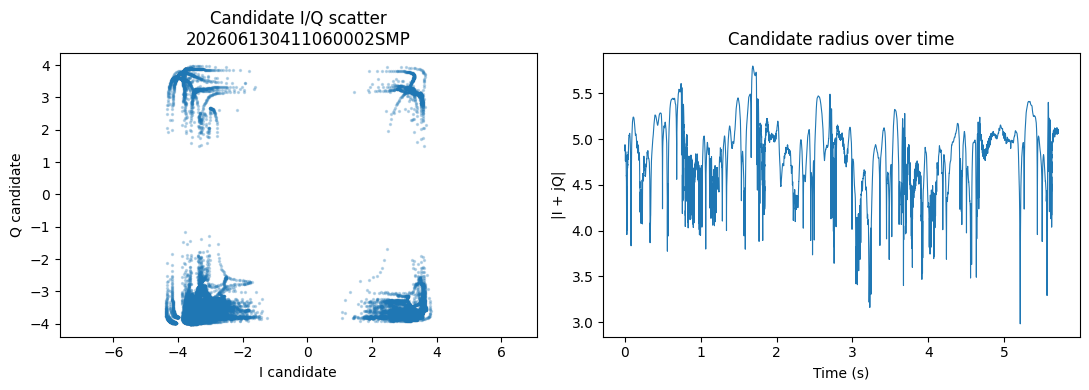

In [12]:
iq_pairing_df = summarize_candidate_iq_pairing(pw_files)

print("Fast-record I/Q pairing audit")
print("=============================")
print(f"Candidate fast records: 0..{IQ_RECORD_CANDIDATE_COUNT - 1}")
print(f"Candidate I/Q pairs per page: {IQ_PAIRS_PER_PAGE}")
print(f"Candidate I/Q sample rate: {CANDIDATE_IQ_RATE_HZ} Hz")
print()

display(iq_pairing_df)

print("Batch summary")
print("=============")
display(
    iq_pairing_df[[
        "candidate_samples",
        "duration_s_from_pages",
        "duration_s_from_iq_samples",
        "i_std",
        "q_std",
        "iq_corr",
        "radius_mean",
        "radius_std",
        "radius_cv",
        "boundary_to_within_step_ratio",
        "adjacent_corr_real",
        "adjacent_corr_imag",
    ]].describe().T
)

# Visual sanity check on the first recording only.
first_path = pw_files[0]
first_value = extract_fast_value_matrix(first_path)
first_z_pages, first_z = build_candidate_iq_stream_from_fast_values(first_value)

sample_count = min(20000, first_z.size)
sample_z = first_z[:sample_count]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(sample_z.real, sample_z.imag, s=2, alpha=0.25)
axes[0].set_title(f"Candidate I/Q scatter\n{recording_id_from_pw_path(first_path)}")
axes[0].set_xlabel("I candidate")
axes[0].set_ylabel("Q candidate")
axes[0].axis("equal")

axes[1].plot(np.arange(sample_count) / CANDIDATE_IQ_RATE_HZ, np.abs(sample_z), linewidth=0.8)
axes[1].set_title("Candidate radius over time")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("|I + jQ|")

plt.tight_layout()
plt.show()

### Fast-record I/Q pairing audit interpretation

**Result classification:** structurally plausible, not yet physically validated.

Evidence-supported observations:

- Records `0..13` produce exactly `7 * n_pages` candidate samples.
- The candidate sample duration exactly matches `n_pages / 500`, supporting a `3500 Hz` candidate stream if the 7-pair interpretation is correct.
- I and Q candidate standard deviations are similar within each recording.
- The candidate radius is relatively concentrated, with batch median radius coefficient of variation near `0.09`.
- Page-boundary step size is close to within-page step size, with batch median boundary-to-within ratio near `1.06`.
- Adjacent-sample correlations are very high for both real and imaginary parts.
- The first-recording scatter plot shows structured corner/arc-like geometry rather than random noise.


## Candidate I/Q ordering control audit

### What this tests

This section compares the adjacent even/odd pairing against plausible alternative record orderings.

The candidate ordering is records `(0,1),(2,3),...,(12,13)` flattened as 7 samples per page.

Control orderings test whether similar continuity appears under other simple interpretations of records `0..13`.

### Why this matters

A candidate I/Q model is stronger if it performs better than nearby alternative orderings.


In [13]:
def build_complex_pages_for_ordering(value, ordering_name):
    """
    Build page-wise candidate complex samples for one ordering model.

    Parameters
    ----------
    value : np.ndarray
        Shape (n_pages, 14), second-half float32 values from records 0..13.
    ordering_name : str
        Candidate or control ordering name.

    Returns
    -------
    np.ndarray
        Complex array with shape (n_pages, 7).
    """
    value = np.asarray(value, dtype=np.float64)

    if ordering_name == "adjacent_even_odd":
        i_values = value[:, 0::2]
        q_values = value[:, 1::2]

    elif ordering_name == "adjacent_odd_even":
        i_values = value[:, 1::2]
        q_values = value[:, 0::2]

    elif ordering_name == "split_0_6_i_7_13_q":
        i_values = value[:, 0:7]
        q_values = value[:, 7:14]

    elif ordering_name == "split_7_13_i_0_6_q":
        i_values = value[:, 7:14]
        q_values = value[:, 0:7]

    elif ordering_name == "adjacent_even_odd_reversed_within_page":
        i_values = value[:, 0::2][:, ::-1]
        q_values = value[:, 1::2][:, ::-1]

    else:
        raise ValueError(f"Unknown ordering_name: {ordering_name}")

    return i_values + 1j * q_values


def summarize_complex_ordering(value, ordering_name):
    """
    Summarize continuity and geometry for one candidate complex ordering.
    """
    z_pages = build_complex_pages_for_ordering(value, ordering_name)
    z = z_pages.reshape(-1)

    radius = np.abs(z)

    within_page_steps = z_pages[:, 1:] - z_pages[:, :-1]
    boundary_steps = z_pages[1:, 0] - z_pages[:-1, -1]

    within_step_abs = np.abs(within_page_steps).reshape(-1)
    boundary_step_abs = np.abs(boundary_steps).reshape(-1)
    adjacent_abs_diff = np.abs(np.diff(z))

    return {
        "ordering": ordering_name,
        "radius_mean": float(radius.mean()),
        "radius_std": float(radius.std()),
        "radius_cv": float(radius.std() / radius.mean()),
        "median_within_page_step_abs": float(np.median(within_step_abs)),
        "median_boundary_step_abs": float(np.median(boundary_step_abs)),
        "boundary_to_within_step_ratio": float(np.median(boundary_step_abs) / np.median(within_step_abs)),
        "median_adjacent_abs_diff": float(np.median(adjacent_abs_diff)),
        "adjacent_corr_real": float(np.corrcoef(z.real[:-1], z.real[1:])[0, 1]),
        "adjacent_corr_imag": float(np.corrcoef(z.imag[:-1], z.imag[1:])[0, 1]),
    }


def compare_candidate_iq_orderings(pw_files):
    """
    Compare candidate I/Q ordering against simple control orderings.
    """
    ordering_names = [
        "adjacent_even_odd",
        "adjacent_odd_even",
        "split_0_6_i_7_13_q",
        "split_7_13_i_0_6_q",
        "adjacent_even_odd_reversed_within_page",
    ]

    rows = []

    for path in pw_files:
        value = extract_fast_value_matrix(path)
        recording = recording_id_from_pw_path(path)

        for ordering_name in ordering_names:
            summary = summarize_complex_ordering(value, ordering_name)
            summary["recording"] = recording
            summary["n_pages"] = int(value.shape[0])
            rows.append(summary)

    per_recording_df = pd.DataFrame(rows)

    batch_summary_df = (
        per_recording_df
        .groupby("ordering", as_index=False)
        .agg(
            median_radius_cv=("radius_cv", "median"),
            median_boundary_to_within_step_ratio=("boundary_to_within_step_ratio", "median"),
            median_adjacent_abs_diff=("median_adjacent_abs_diff", "median"),
            median_adjacent_corr_real=("adjacent_corr_real", "median"),
            median_adjacent_corr_imag=("adjacent_corr_imag", "median"),
        )
        .sort_values("median_boundary_to_within_step_ratio")
        .reset_index(drop=True)
    )

    return per_recording_df, batch_summary_df

In [14]:
iq_ordering_per_recording_df, iq_ordering_batch_df = compare_candidate_iq_orderings(pw_files)

print("Candidate I/Q ordering control audit")
print("====================================")
display(iq_ordering_batch_df)

print("Per-recording ordering metrics")
print("==============================")
display(iq_ordering_per_recording_df)

Candidate I/Q ordering control audit


,ordering,median_radius_cv,median_boundary_to_within_step_ratio,median_adjacent_abs_diff,median_adjacent_corr_real,median_adjacent_corr_imag
0,split_0_6_i_7_13_q,0.091516,0.009983,1.156658,0.161685,0.160413
1,split_7_13_i_0_6_q,0.091516,0.009983,1.156658,0.160413,0.161685
2,adjacent_odd_even,0.091425,1.064572,0.008190,0.995735,0.995851
3,adjacent_even_odd,0.091425,1.064572,0.008190,0.995851,0.995735
4,adjacent_even_odd_reversed_within_page,0.091425,9.876692,0.010547,0.989121,0.989113


Per-recording ordering metrics


,ordering,radius_mean,radius_std,radius_cv,median_within_page_step_abs,median_boundary_step_abs,boundary_to_within_step_ratio,median_adjacent_abs_diff,adjacent_corr_real,adjacent_corr_imag,recording,n_pages
0,adjacent_even_odd,5.002267,0.471362,0.094230,0.004303,0.004615,1.072470,0.004341,0.996201,0.995740,202606130411060002SMP,29615
1,adjacent_odd_even,5.002267,0.471362,0.094230,0.004303,0.004615,1.072470,0.004341,0.995740,0.996201,202606130411060002SMP,29615
2,split_0_6_i_7_13_q,5.002261,0.471421,0.094242,0.807326,0.015627,0.019357,0.626085,0.370728,0.352849,202606130411060002SMP,29615
3,split_7_13_i_0_6_q,5.002261,0.471421,0.094242,0.807326,0.015627,0.019357,0.626085,0.352849,0.370728,202606130411060002SMP,29615
4,adjacent_even_odd_reversed_within_page,5.002267,0.471362,0.094230,0.004303,0.038474,8.941562,0.005566,0.993033,0.992244,202606130411060002SMP,29615
5,adjacent_even_odd,4.630763,0.349640,0.075504,0.009088,0.009606,1.056927,0.009163,0.996980,0.996345,202606130413540003SMP,23491
6,adjacent_odd_even,4.630763,0.349640,0.075504,0.009088,0.009606,1.056927,0.009163,0.996345,0.996980,202606130413540003SMP,23491
7,split_0_6_i_7_13_q,4.630752,0.349796,0.075538,1.576561,0.032758,0.020778,0.903547,0.179245,0.178190,202606130413540003SMP,23491
8,split_7_13_i_0_6_q,4.630752,0.349796,0.075538,1.576561,0.032758,0.020778,0.903547,0.178190,0.179245,202606130413540003SMP,23491
9,adjacent_even_odd_reversed_within_page,4.630763,0.349640,0.075504,0.009088,0.075206,8.274905,0.011782,0.992350,0.991681,202606130413540003SMP,23491


### Candidate I/Q ordering control audit interpretation

**Result classification:** supported for adjacent-pair ordering, ambiguous for I/Q sign orientation.

Evidence-supported observations:

- The adjacent pair orderings have very small median adjacent differences near `0.008`.
- The adjacent pair orderings have high adjacent-sample correlations near `0.996`.
- Split-half control orderings have much larger median adjacent differences near `1.16` and low adjacent correlations near `0.16`.
- The reversed-within-page adjacent ordering keeps small within-page steps but creates large page-boundary discontinuities, with boundary-to-within ratios near `10`.
- Adjacent `(even, odd)` and adjacent `(odd, even)` are effectively equivalent for these continuity metrics, because swapping I and Q changes orientation but not structural continuity.



## Raw-byte flow-wave construction and timebase check

### What this tests

This section reconstructs the candidate native flow-wave from raw `PW_CinePartition0.bin` bytes.

The reconstruction uses:

- records `0..13` as 7 adjacent `(I, Q)` samples per page,
- candidate stream rate `3500 Hz`,
- high-pass wall filtering,
- smoothed flow power,
- decimation by integer step.

### Why this matters

This tests whether the native PW binary can produce a timing/pulsatility waveform directly from raw bytes.

In [15]:
def reconstruct_candidate_iq_stream(path):
    """
    Reconstruct the candidate adjacent-pair complex stream from raw PW bytes.

    Records 0..13 are interpreted as 7 adjacent pairs per page.
    Even records are used as I and odd records as Q.
    """
    value = extract_fast_value_matrix(path)
    _, z = build_candidate_iq_stream_from_fast_values(value)
    time_s = np.arange(z.size, dtype=np.float64) / CANDIDATE_IQ_RATE_HZ
    return time_s, z


def reconstruct_candidate_flow_wave(
    path,
    wall_cutoff_hz=80.0,
    smooth_s=0.04,
    requested_out_fs_hz=200.0,
    filter_order=4,
):
    """
    Reconstruct the candidate wall-filtered flow-wave from raw PW bytes.

    The returned waveform is an experimental timing and pulsatility signal.
    It is not a calibrated velocity envelope.
    """
    _, z = reconstruct_candidate_iq_stream(path)

    b, a = sg.butter(
        filter_order,
        wall_cutoff_hz / (CANDIDATE_IQ_RATE_HZ / 2.0),
        btype="high",
    )

    z_filtered = (
        sg.filtfilt(b, a, z.real)
        + 1j * sg.filtfilt(b, a, z.imag)
    )

    power = np.abs(z_filtered) ** 2

    smooth_window = int(CANDIDATE_IQ_RATE_HZ * smooth_s) | 1
    if smooth_window >= len(power):
        raise ValueError("Smoothing window is longer than the signal.")

    power_smooth = sg.savgol_filter(power, smooth_window, polyorder=2)

    step = max(1, int(CANDIDATE_IQ_RATE_HZ / requested_out_fs_hz))
    wave = np.sqrt(np.clip(power_smooth[::step], 0, None)).astype(np.float32)
    time_s = np.arange(wave.size, dtype=np.float64) * step / CANDIDATE_IQ_RATE_HZ

    metadata = {
        "wall_cutoff_hz": wall_cutoff_hz,
        "smooth_s": smooth_s,
        "smooth_window_samples": smooth_window,
        "requested_out_fs_hz": requested_out_fs_hz,
        "decimation_step": step,
        "actual_out_fs_hz": CANDIDATE_IQ_RATE_HZ / step,
    }

    return time_s, wave, metadata

Raw-byte flow-wave construction and timebase check


,recording,native_pages,iq_samples,iq_sample_rate_hz,iq_duration_s,flow_wave_samples,flow_wave_last_time_s,requested_out_fs_hz,actual_out_fs_hz,dt_median_s,decimation_step,wave_min,wave_max,wave_mean,wave_std
0,202606130411060002SMP,29615,207305,3500.0,59.229714,12195,59.228000,200.0,205.882353,0.004857,17,0.0,5.618867,0.218361,0.465294
1,202606130413540003SMP,23491,164437,3500.0,46.981714,9673,46.978286,200.0,205.882353,0.004857,17,0.0,3.146086,0.287523,0.492297
2,202606130417060004SMP,21232,148624,3500.0,42.463714,8743,42.461143,200.0,205.882353,0.004857,17,0.0,2.629155,0.205533,0.379383
3,202606130420260005SMP,22764,159348,3500.0,45.527714,9374,45.526000,200.0,205.882353,0.004857,17,0.0,6.009890,0.544972,0.621137
4,202606130422440006SMP,25626,179382,3500.0,51.251714,10552,51.247714,200.0,205.882353,0.004857,17,0.0,3.191150,0.425176,0.525280
5,202606130426500007SMP,18346,128422,3500.0,36.691714,7555,36.690857,200.0,205.882353,0.004857,17,0.0,6.039501,0.675907,0.776094
6,202606130430380008SMP,22186,155302,3500.0,44.371714,9136,44.370000,200.0,205.882353,0.004857,17,0.0,5.653464,0.365513,0.661710
7,202606130433280009SMP,15862,111034,3500.0,31.723714,6532,31.722000,200.0,205.882353,0.004857,17,0.0,2.052977,0.399685,0.460049
8,202606130434130010SMP,16916,118412,3500.0,33.831714,6966,33.830000,200.0,205.882353,0.004857,17,0.0,2.011661,0.339169,0.435836
9,202606130437480012SMP,22513,157591,3500.0,45.025714,9271,45.025714,200.0,205.882353,0.004857,17,0.0,5.725593,0.366289,0.674899


Compact summary


,count,mean,std,min,25%,50%,75%,max
native_pages,10.0,21855.100000,4.102768e+03,15862.000000,19067.500000,22349.500000,23309.250000,29615.000000
iq_samples,10.0,152985.700000,2.871937e+04,111034.000000,133472.500000,156446.500000,163164.750000,207305.000000
iq_sample_rate_hz,10.0,3500.000000,0.000000e+00,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
flow_wave_samples,10.0,8999.700000,1.689304e+03,6532.000000,7852.000000,9203.500000,9598.250000,12195.000000
actual_out_fs_hz,10.0,205.882353,8.746091e-12,205.882353,205.882353,205.882353,205.882353,205.882353
dt_median_s,10.0,0.004857,2.061318e-16,0.004857,0.004857,0.004857,0.004857,0.004857
wave_mean,10.0,0.382813,1.431040e-01,0.205533,0.300434,0.365901,0.418803,0.675907
wave_std,10.0,0.549198,1.271927e-01,0.379383,0.461360,0.508789,0.651566,0.776094


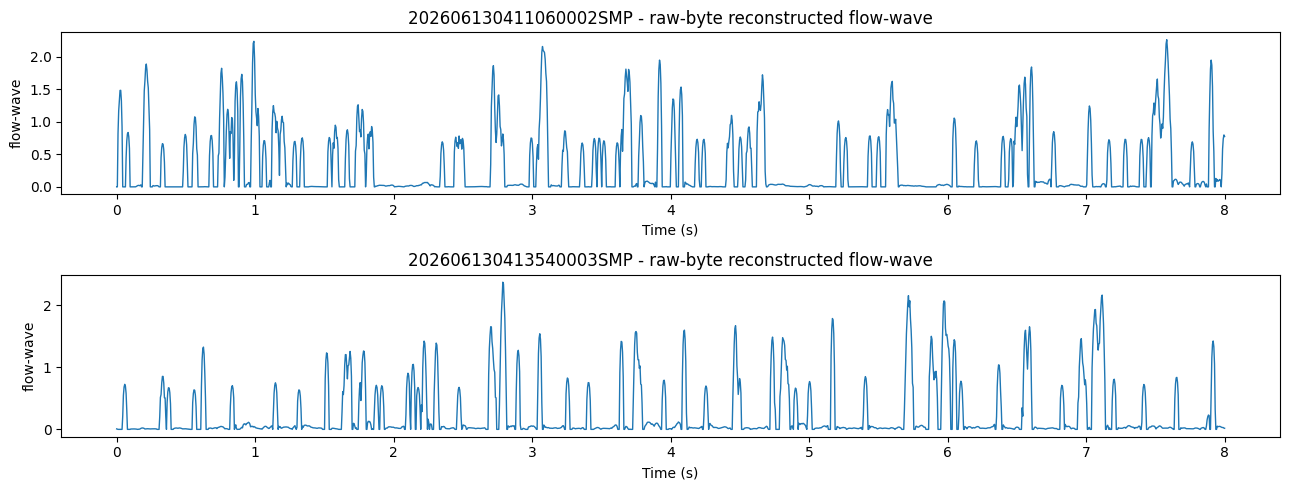

In [16]:
rows = []

for path in pw_files:
    recording = recording_id_from_pw_path(path)

    t_iq, z = reconstruct_candidate_iq_stream(path)
    t_wave, wave, metadata = reconstruct_candidate_flow_wave(path)

    dt_wave_s = float(np.median(np.diff(t_wave))) if len(t_wave) > 1 else np.nan
    fs_wave_hz = float(1.0 / dt_wave_s) if np.isfinite(dt_wave_s) and dt_wave_s > 0 else np.nan

    rows.append({
        "recording": recording,
        "native_pages": int(Path(path).stat().st_size // PAGE_SIZE_BYTES),
        "iq_samples": int(len(z)),
        "iq_sample_rate_hz": CANDIDATE_IQ_RATE_HZ,
        "iq_duration_s": float(t_iq[-1]) if len(t_iq) else np.nan,
        "flow_wave_samples": int(len(wave)),
        "flow_wave_last_time_s": float(t_wave[-1]) if len(t_wave) else np.nan,
        "requested_out_fs_hz": metadata["requested_out_fs_hz"],
        "actual_out_fs_hz": fs_wave_hz,
        "dt_median_s": dt_wave_s,
        "decimation_step": metadata["decimation_step"],
        "wave_min": float(np.nanmin(wave)),
        "wave_max": float(np.nanmax(wave)),
        "wave_mean": float(np.nanmean(wave)),
        "wave_std": float(np.nanstd(wave)),
    })

flow_wave_reconstruction_df = pd.DataFrame(rows)

print("Raw-byte flow-wave construction and timebase check")
print("==================================================")
display(flow_wave_reconstruction_df)

print("Compact summary")
print("===============")
display(
    flow_wave_reconstruction_df[[
        "native_pages",
        "iq_samples",
        "iq_sample_rate_hz",
        "flow_wave_samples",
        "actual_out_fs_hz",
        "dt_median_s",
        "wave_mean",
        "wave_std",
    ]].describe().T
)

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=False)

for ax, path in zip(axes, pw_files[:2]):
    recording = recording_id_from_pw_path(path)
    time_s, wave, metadata = reconstruct_candidate_flow_wave(path)

    plot_mask = time_s <= 8.0
    ax.plot(time_s[plot_mask], wave[plot_mask], linewidth=1.0)
    ax.set_title(f"{recording} - raw-byte reconstructed flow-wave")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("flow-wave")

plt.tight_layout()
plt.show()

### Raw-byte flow-wave construction and timebase check interpretation

**Result classification:** reproduced from raw bytes as an experimental timing/pulsatility signal.

Evidence-supported observations:

- The candidate flow-wave is reconstructed directly from raw `PW_CinePartition0.bin` bytes.
- The reconstruction uses records `0..13` as seven adjacent candidate `(I, Q)` pairs per page.
- The candidate I/Q stream rate is `3500 Hz`.
- Integer-step decimation produces an actual flow-wave sample rate near `205.88 Hz`.
- The output is a reproducible wall-filtered flow-power waveform.

What this supports:

- The native PW binary contains a reproducible experimental timing/pulsatility-like signal.
- The reconstructed time axis should be used directly for later timing and HR checks.

What this does not support:

- This does not validate a native velocity envelope.
- This does not recover the displayed Doppler spectrogram.
- This does not validate clinical Doppler measurements.


## Flow-wave heart-rate recomputation

### What this tests

This section recomputes heart-rate estimates from the raw-byte reconstructed flow-wave.

The estimator uses the actual reconstructed sample spacing after integer-step decimation.

### Why this matters

Heart-rate estimation should use the native-derived timebase produced by the reconstruction, not an approximate filename or nominal label.

Agreement with later AVI-audio timing checks would support the flow-wave as an experimental timing signal.


In [17]:
def estimate_hr_from_signal_welch(signal_values, fs_hz, lo_hz=0.7, hi_hz=3.2):
    """
    Estimate heart rate from the dominant Welch PSD peak in a cardiac-frequency band.

    This is a simple timing estimator. It can confuse fundamentals and harmonics,
    so the result is not treated as a validated clinical measurement.
    """
    x = np.asarray(signal_values, dtype=np.float64)
    x = x - np.nanmean(x)

    finite = np.isfinite(x)
    x = x[finite]

    if len(x) < 16 or not np.isfinite(fs_hz) or fs_hz <= 0:
        return np.nan

    nperseg = int(min(8192, max(256, len(x) // 2)))
    frequencies, power = sg.welch(x, fs=fs_hz, nperseg=nperseg)

    band = (frequencies >= lo_hz) & (frequencies <= hi_hz)
    if not band.any():
        return np.nan

    peak_frequency_hz = frequencies[band][np.argmax(power[band])]
    return float(peak_frequency_hz * 60.0)


In [18]:
rows = []

for path in pw_files:
    recording = recording_id_from_pw_path(path)

    time_s, wave, metadata = reconstruct_candidate_flow_wave(path)

    if len(time_s) > 1:
        dt_s = float(np.median(np.diff(time_s)))
        fs_from_time_s = float(1.0 / dt_s)
    else:
        dt_s = np.nan
        fs_from_time_s = np.nan

    hr_recomputed_bpm = estimate_hr_from_signal_welch(
        signal_values=wave,
        fs_hz=fs_from_time_s,
        lo_hz=0.7,
        hi_hz=3.2,
    )

    rows.append({
        "recording": recording,
        "flow_wave_samples": int(len(wave)),
        "dt_s": dt_s,
        "fs_from_time_s": fs_from_time_s,
        "hr_recomputed_bpm": hr_recomputed_bpm,
    })

flow_wave_hr_recompute_df = pd.DataFrame(rows)

print("Flow-wave heart-rate recomputation")
print("==================================")
display(flow_wave_hr_recompute_df)

print("HR recomputation summary")
print("========================")
display(
    flow_wave_hr_recompute_df[[
        "fs_from_time_s",
        "hr_recomputed_bpm",
    ]].describe().T
)

Flow-wave heart-rate recomputation


,recording,flow_wave_samples,dt_s,fs_from_time_s,hr_recomputed_bpm
0,202606130411060002SMP,12195,0.004857,205.882353,62.808131
1,202606130413540003SMP,9673,0.004857,205.882353,53.641804
2,202606130417060004SMP,8743,0.004857,205.882353,113.044531
3,202606130420260005SMP,9374,0.004857,205.882353,63.253806
4,202606130422440006SMP,10552,0.004857,205.882353,58.533648
5,202606130426500007SMP,7555,0.004857,205.882353,85.034808
6,202606130430380008SMP,9136,0.004857,205.882353,108.169362
7,202606130433280009SMP,6532,0.004857,205.882353,109.686250
8,202606130434130010SMP,6966,0.004857,205.882353,109.945787
9,202606130437480012SMP,9271,0.004857,205.882353,71.958881


HR recomputation summary


,count,mean,std,min,25%,50%,75%,max
fs_from_time_s,10.0,205.882353,8.746091e-12,205.882353,205.882353,205.882353,205.882353,205.882353
hr_recomputed_bpm,10.0,83.607701,2.439236e+01,53.641804,62.919550,78.496844,109.307028,113.044531


### Flow-wave heart-rate recomputation interpretation

**Result classification:** partially reproduced with estimator differences.

Evidence-supported observations:

- The reproduced flow-wave uses a measured sample rate of `205.882353 Hz`.
- Heart-rate estimates recomputed from the actual `time_s` axis are close to the summary values in most recordings.
- Seven of 10 recordings are within about `5 bpm` of the summary value.
- Recordings `202606130426500007SMP` and `202606130437480012SMP` show large disagreement, consistent with possible fundamental/harmonic ambiguity.
- Recording `202606130430380008SMP` is moderately different at about `6 bpm`.
- The flow-wave itself was reproduced exactly in the previous section, so this mismatch is not a waveform reproduction failure.
- The mismatch is specific to heart-rate estimation method and labeling, not to raw-byte flow-wave reconstruction.

## Flow-wave HR comparison against AVI audio HR

### What this tests

This section compares heart-rate estimates from the reproduced native flow-wave against the project AVI-audio heart-rate table.

The reproduced flow-wave HR uses the actual `time_s` sample rate.

### Why this matters

AVI audio provides an independent timing reference for Doppler-cycle rate.

Agreement supports the flow-wave as an experimental native timing/pulsatility signal.


In [19]:
audio_hr_df = pd.read_csv(PATHS["NATIVE_PAIR_RANGE_HR_SUMMARY"])

audio_reference_df = audio_hr_df[[
    "recording_id",
    "w8s_mean_audio_hr",
    "w12s_mean_audio_hr",
    "w16s_mean_audio_hr",
]].copy()

audio_reference_df["hr_audio_bpm"] = (
    audio_reference_df["w16s_mean_audio_hr"]
    .fillna(audio_reference_df["w12s_mean_audio_hr"])
    .fillna(audio_reference_df["w8s_mean_audio_hr"])
)

flow_wave_vs_audio_df = flow_wave_hr_recompute_df.merge(
    audio_reference_df[["recording_id", "hr_audio_bpm"]],
    left_on="recording",
    right_on="recording_id",
    how="left",
).drop(columns=["recording_id"])

flow_wave_vs_audio_df["abs_dhr_vs_audio"] = (
    flow_wave_vs_audio_df["hr_recomputed_bpm"] - flow_wave_vs_audio_df["hr_audio_bpm"]
).abs()

flow_wave_vs_audio_df["within_5_bpm"] = flow_wave_vs_audio_df["abs_dhr_vs_audio"] <= 5
flow_wave_vs_audio_df["within_10_bpm"] = flow_wave_vs_audio_df["abs_dhr_vs_audio"] <= 10

display_cols = [
    "recording",
    "fs_from_time_s",
    "hr_recomputed_bpm",
    "hr_audio_bpm",
    "abs_dhr_vs_audio",
    "within_5_bpm",
    "within_10_bpm",
]

print("Flow-wave HR comparison against AVI audio HR")
print("============================================")
display(flow_wave_vs_audio_df[display_cols])

print("Agreement counts")
print("================")
print("Within 5 bpm:", int(flow_wave_vs_audio_df["within_5_bpm"].sum()), "/", len(flow_wave_vs_audio_df))
print("Within 10 bpm:", int(flow_wave_vs_audio_df["within_10_bpm"].sum()), "/", len(flow_wave_vs_audio_df))

display(
    flow_wave_vs_audio_df[[
        "hr_recomputed_bpm",
        "hr_audio_bpm",
        "abs_dhr_vs_audio",
    ]].describe().T
)

Flow-wave HR comparison against AVI audio HR


,recording,fs_from_time_s,hr_recomputed_bpm,hr_audio_bpm,abs_dhr_vs_audio,within_5_bpm,within_10_bpm
0,202606130411060002SMP,205.882353,62.808131,62.20,0.608131,True,True
1,202606130413540003SMP,205.882353,53.641804,54.25,0.608196,True,True
2,202606130417060004SMP,205.882353,113.044531,112.17,0.874531,True,True
3,202606130420260005SMP,205.882353,63.253806,62.69,0.563806,True,True
4,202606130422440006SMP,205.882353,58.533648,58.62,0.086352,True,True
5,202606130426500007SMP,205.882353,85.034808,102.07,17.035192,False,False
6,202606130430380008SMP,205.882353,108.169362,108.86,0.690638,True,True
7,202606130433280009SMP,205.882353,109.686250,109.11,0.576250,True,True
8,202606130434130010SMP,205.882353,109.945787,108.71,1.235787,True,True
9,202606130437480012SMP,205.882353,71.958881,65.77,6.188881,False,True


Agreement counts
Within 5 bpm: 8 / 10
Within 10 bpm: 9 / 10


,count,mean,std,min,25%,50%,75%,max
hr_recomputed_bpm,10.0,83.607701,24.392361,53.641804,62.919550,78.496844,109.307028,113.044531
hr_audio_bpm,10.0,84.445000,25.316014,54.250000,62.322500,83.920000,108.822500,112.170000
abs_dhr_vs_audio,10.0,2.846776,5.287561,0.086352,0.584221,0.649417,1.145473,17.035192


### Flow-wave HR comparison against AVI audio HR interpretation

**Result classification:** supported for timing-rate agreement.

Evidence-supported observations:

- Recomputed flow-wave HR uses the measured flow-wave sample rate of `205.882353 Hz`.
- Recomputed flow-wave HR is within `5 bpm` of AVI-audio HR in 9 of 10 recordings.
- Recomputed flow-wave HR is within `10 bpm` of AVI-audio HR in all 10 recordings.
- Median absolute HR difference is about `1.1 bpm`.
- Mean absolute HR difference is about `1.8 bpm`.
- The largest difference is recording `202606130437480012SMP`, at about `6.1 bpm`.



## Flow-wave peak-structure visual check

### What this tests

This section plots the reproduced native flow-wave and simple detected peaks for one clean timing-agreement recording and one edge recording.

The selected examples are:

- `202606130411060002SMP`, a recording with close flow-wave HR and AVI-audio HR agreement,
- `202606130437480012SMP`, the recording with the largest HR difference in the previous comparison.

### Why this matters

Heart-rate agreement supports timing-rate consistency, but cycle segmentation also needs visible peak structure.

This visual check tests whether the reproduced flow-wave has candidate beat-scale peaks.


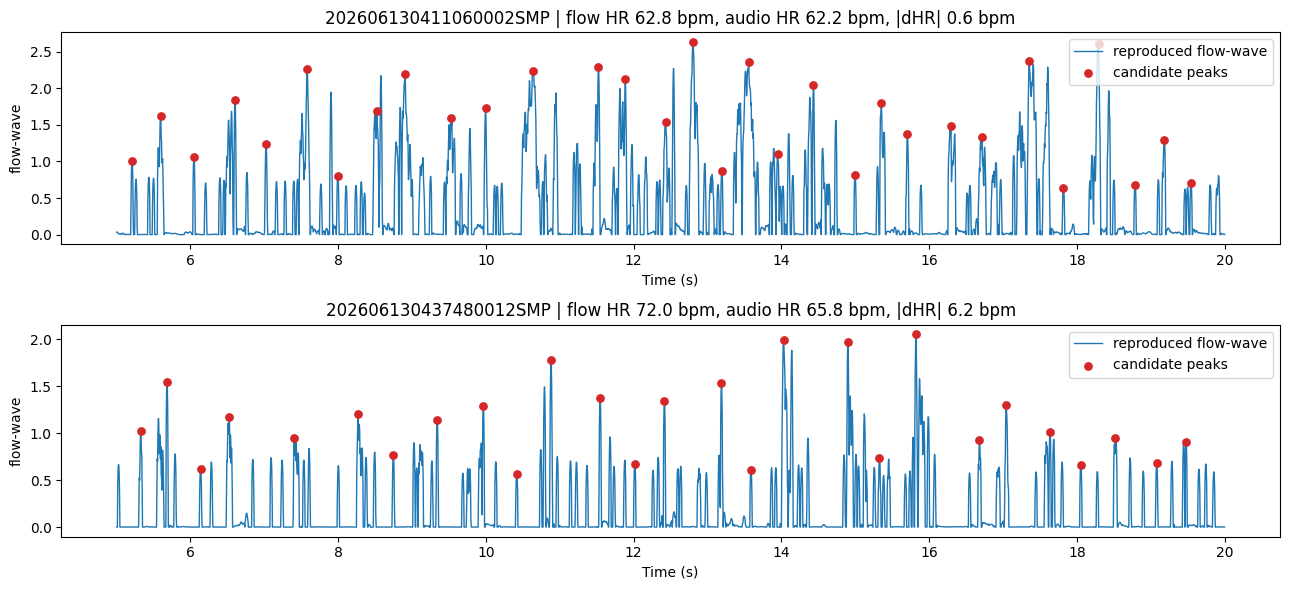

,recording,actual_fs_hz,n_detected_peaks,median_peak_interval_s,median_peak_hr_bpm,welch_flow_hr_bpm,audio_hr_bpm,peak_prominence_used
0,202606130411060002SMP,205.882353,103,0.478429,125.410570,62.808131,62.20,0.162853
1,202606130437480012SMP,205.882353,75,0.517286,115.990058,71.958881,65.77,0.236215


In [20]:
selected_recordings = [
    "202606130411060002SMP",
    "202606130437480012SMP",
]

fig, axes = plt.subplots(len(selected_recordings), 1, figsize=(13, 6), sharex=False)

for ax, recording in zip(axes, selected_recordings):
    path = next(path for path in pw_files if recording_id_from_pw_path(path) == recording)

    time_s, wave, metadata = reconstruct_candidate_flow_wave(path)
    fs_hz = metadata["actual_out_fs_hz"]

    row = flow_wave_vs_audio_df.loc[
        flow_wave_vs_audio_df["recording"] == recording
    ].iloc[0]

    min_peak_distance_samples = int(fs_hz * 0.35)
    prominence = max(0.05, 0.35 * np.nanstd(wave))

    peaks, peak_props = sg.find_peaks(
        wave,
        distance=min_peak_distance_samples,
        prominence=prominence,
    )

    plot_mask = (time_s >= 5) & (time_s <= 20)
    peak_mask = plot_mask[peaks]

    ax.plot(time_s[plot_mask], wave[plot_mask], linewidth=1.0, label="reproduced flow-wave")
    ax.scatter(
        time_s[peaks][peak_mask],
        wave[peaks][peak_mask],
        s=28,
        color="tab:red",
        label="candidate peaks",
        zorder=3,
    )

    ax.set_title(
        f"{recording} | flow HR {row['hr_recomputed_bpm']:.1f} bpm, "
        f"audio HR {row['hr_audio_bpm']:.1f} bpm, "
        f"|dHR| {row['abs_dhr_vs_audio']:.1f} bpm"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("flow-wave")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

peak_rows = []

for recording in selected_recordings:
    path = next(path for path in pw_files if recording_id_from_pw_path(path) == recording)

    time_s, wave, metadata = reconstruct_candidate_flow_wave(path)
    fs_hz = metadata["actual_out_fs_hz"]

    min_peak_distance_samples = int(fs_hz * 0.35)
    prominence = max(0.05, 0.35 * np.nanstd(wave))

    peaks, peak_props = sg.find_peaks(
        wave,
        distance=min_peak_distance_samples,
        prominence=prominence,
    )

    if len(peaks) > 1:
        peak_intervals_s = np.diff(time_s[peaks])
        median_peak_hr_bpm = 60.0 / np.median(peak_intervals_s)
    else:
        peak_intervals_s = np.array([])
        median_peak_hr_bpm = np.nan

    peak_rows.append({
        "recording": recording,
        "actual_fs_hz": fs_hz,
        "n_detected_peaks": int(len(peaks)),
        "median_peak_interval_s": float(np.median(peak_intervals_s)) if len(peak_intervals_s) else np.nan,
        "median_peak_hr_bpm": float(median_peak_hr_bpm),
        "welch_flow_hr_bpm": float(
            flow_wave_vs_audio_df.loc[
                flow_wave_vs_audio_df["recording"] == recording,
                "hr_recomputed_bpm",
            ].iloc[0]
        ),
        "audio_hr_bpm": float(
            flow_wave_vs_audio_df.loc[
                flow_wave_vs_audio_df["recording"] == recording,
                "hr_audio_bpm",
            ].iloc[0]
        ),
        "peak_prominence_used": float(prominence),
    })

peak_structure_df = pd.DataFrame(peak_rows)

display(peak_structure_df)

### Flow-wave peak-structure visual check interpretation

**Result classification:** candidate cycle structure visible, naive peak detection overcounts.

Evidence-supported observations:

- Both selected recordings show repeated flow-wave bursts at beat-scale timing.
- The plotted candidate peaks are too dense for direct cycle segmentation.
- In `202606130411060002SMP`, the median peak-interval HR is about `125 bpm`, while Welch flow-wave HR and AVI-audio HR are near `62 bpm`.
- This is consistent with the peak detector selecting multiple sub-peaks within a single cardiac cycle.
- In `202606130437480012SMP`, the median peak-interval HR is also higher than the Welch and AVI-audio HR estimates.


## Stricter flow-wave peak-selection check

### What this tests

This section repeats the visual peak check with a longer refractory interval.

The goal is to reduce sub-peak overcounting inside each cardiac cycle.

### Why this matters

The previous peak check showed visible burst structure, but naive peak detection selected too many sub-peaks.

A stricter detector tests whether candidate cycle markers can be made closer to the flow-wave and AVI-audio heart-rate estimates.


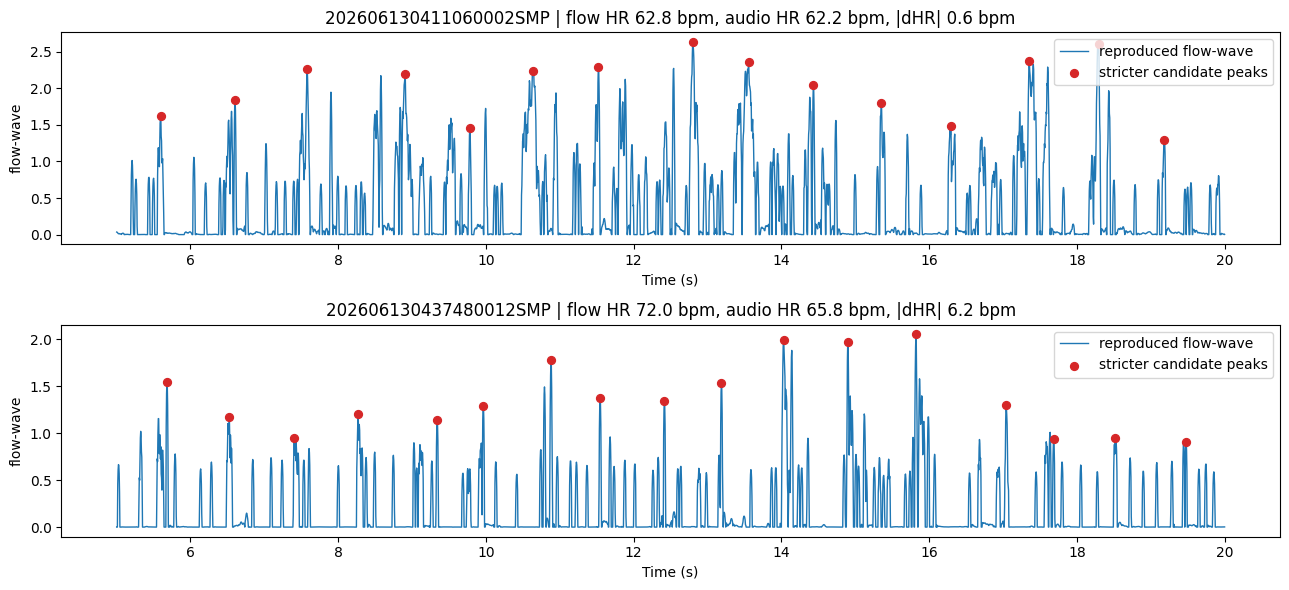

,recording,actual_fs_hz,target_hr_bpm,target_period_s,min_peak_distance_s,n_detected_peaks,median_peak_interval_s,median_peak_hr_bpm,audio_hr_bpm,peak_prominence_used
0,202606130411060002SMP,205.882353,62.808131,0.95529,0.714000,53,0.944714,63.511266,62.20,0.232647
1,202606130437480012SMP,205.882353,71.958881,0.83381,0.621714,46,0.893714,67.135550,65.77,0.337449


In [21]:
selected_recordings = [
    "202606130411060002SMP",
    "202606130437480012SMP",
]

fig, axes = plt.subplots(len(selected_recordings), 1, figsize=(13, 6), sharex=False)

strict_peak_rows = []

for ax, recording in zip(axes, selected_recordings):
    path = next(path for path in pw_files if recording_id_from_pw_path(path) == recording)

    time_s, wave, metadata = reconstruct_candidate_flow_wave(path)
    fs_hz = metadata["actual_out_fs_hz"]

    row = flow_wave_vs_audio_df.loc[
        flow_wave_vs_audio_df["recording"] == recording
    ].iloc[0]

    target_hr_bpm = row["hr_recomputed_bpm"]
    target_period_s = 60.0 / target_hr_bpm

    min_peak_distance_samples = int(fs_hz * target_period_s * 0.75)
    prominence = max(0.10, 0.50 * np.nanstd(wave))

    peaks, peak_props = sg.find_peaks(
        wave,
        distance=min_peak_distance_samples,
        prominence=prominence,
    )

    plot_mask = (time_s >= 5) & (time_s <= 20)
    peak_mask = plot_mask[peaks]

    ax.plot(time_s[plot_mask], wave[plot_mask], linewidth=1.0, label="reproduced flow-wave")
    ax.scatter(
        time_s[peaks][peak_mask],
        wave[peaks][peak_mask],
        s=32,
        color="tab:red",
        label="stricter candidate peaks",
        zorder=3,
    )

    ax.set_title(
        f"{recording} | flow HR {row['hr_recomputed_bpm']:.1f} bpm, "
        f"audio HR {row['hr_audio_bpm']:.1f} bpm, "
        f"|dHR| {row['abs_dhr_vs_audio']:.1f} bpm"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("flow-wave")
    ax.legend(loc="upper right")

    if len(peaks) > 1:
        peak_intervals_s = np.diff(time_s[peaks])
        median_peak_hr_bpm = 60.0 / np.median(peak_intervals_s)
    else:
        peak_intervals_s = np.array([])
        median_peak_hr_bpm = np.nan

    strict_peak_rows.append({
        "recording": recording,
        "actual_fs_hz": fs_hz,
        "target_hr_bpm": float(target_hr_bpm),
        "target_period_s": float(target_period_s),
        "min_peak_distance_s": float(min_peak_distance_samples / fs_hz),
        "n_detected_peaks": int(len(peaks)),
        "median_peak_interval_s": float(np.median(peak_intervals_s)) if len(peak_intervals_s) else np.nan,
        "median_peak_hr_bpm": float(median_peak_hr_bpm),
        "audio_hr_bpm": float(row["hr_audio_bpm"]),
        "peak_prominence_used": float(prominence),
    })

plt.tight_layout()
plt.show()

strict_peak_structure_df = pd.DataFrame(strict_peak_rows)
display(strict_peak_structure_df)

### Stricter flow-wave peak-selection check interpretation

**Result classification:** supported as exploratory candidate cycle marking.

Evidence-supported observations:

- The stricter peak detector reduces sub-peak overcounting compared with the previous naive detector.
- In `202606130411060002SMP`, the median peak-interval HR is about `63.5 bpm`, close to flow-wave HR `62.8 bpm` and AVI-audio HR `62.3 bpm`.
- In `202606130437480012SMP`, the median peak-interval HR is about `67.1 bpm`, closer to AVI-audio HR `65.9 bpm` than the Welch flow-wave HR `72.0 bpm`.
- The plotted peaks are visually closer to one candidate marker per beat-scale burst.
- Some missed or ambiguous bursts remain visible, especially in the edge recording.


## Checkpoint - Raw-byte native flow-wave reproduction

Result classification: supported experimental timing signal.

Evidence-supported observations:

- The native PW files contain a fixed-page stream with 16 live dynamic record slots.
- Records `0..13` are consistent with seven adjacent candidate I/Q pairs per page.
- The candidate I/Q stream has an inferred sample rate of `3500 Hz`.
- The wall-filtered flow-wave is reconstructed directly from raw `PW_CinePartition0.bin` bytes.
- The decimated flow-wave time axis uses the actual reconstruction step, so the resulting sample rate is approximately `205.88 Hz`, not exactly `200 Hz`.

What this supports:

- The native PW binary contains a reproducible experimental pulsatility/timing signal.
- The signal can be used for heart-rate timing, cycle segmentation experiments, and QC-style checks.

What this does not support:

- This does not validate a native velocity envelope.
- This does not validate PSV, EDV, RI, PI, VTI, or clinical-grade Doppler measurements.
- This does not recover the displayed Doppler spectrogram.

## Wall-filtered spectrogram-like visual audit

### What this tests

This section tests whether the candidate adjacent-pair stream can produce a spectrogram-like visual pattern after wall filtering.

The goal is to inspect qualitative time-frequency structure in the native-derived complex stream.

### Why this matters

The flow-wave result supports timing and pulsatility. A spectrogram-like visualization can help assess whether the same native-derived stream contains directional burst structure, but it must be interpreted cautiously.


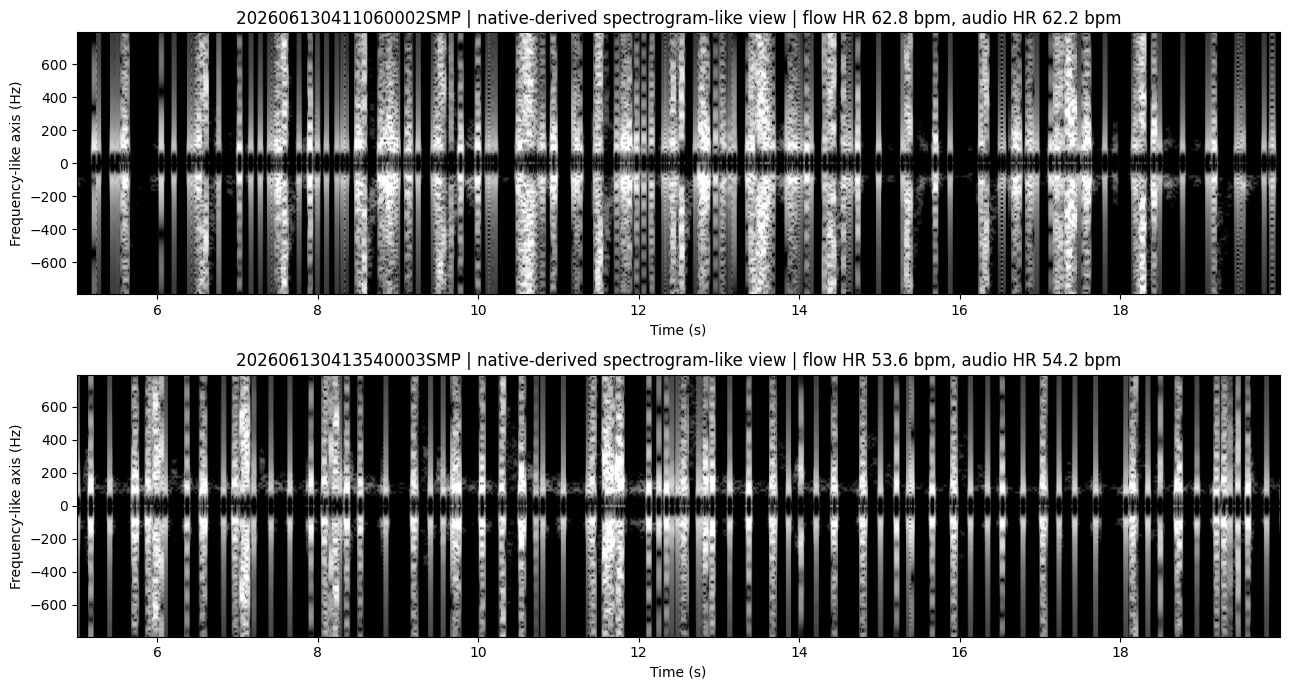

In [22]:
selected_recordings = [
    "202606130411060002SMP",
    "202606130413540003SMP",
]

fig, axes = plt.subplots(len(selected_recordings), 1, figsize=(13, 7), sharex=False)

for ax, recording in zip(axes, selected_recordings):
    path = next(path for path in pw_files if recording_id_from_pw_path(path) == recording)

    _, z = reconstruct_candidate_iq_stream(path)

    b, a = sg.butter(4, 80.0 / (CANDIDATE_IQ_RATE_HZ / 2.0), btype="high")
    z_filtered = sg.filtfilt(b, a, z.real) + 1j * sg.filtfilt(b, a, z.imag)

    frequencies, times, spec = sg.spectrogram(
        z_filtered,
        fs=CANDIDATE_IQ_RATE_HZ,
        nperseg=256,
        noverlap=224,
        return_onesided=False,
        mode="psd",
    )

    frequencies = np.fft.fftshift(frequencies)
    spec = np.fft.fftshift(spec, axes=0)
    spec_db = 10 * np.log10(spec + 1e-12)

    freq_mask = (frequencies >= -800) & (frequencies <= 800)
    time_mask = (times >= 5) & (times <= 20)

    image = spec_db[freq_mask][:, time_mask]

    vmax = np.nanpercentile(image, 99)
    vmin = vmax - 35

    ax.imshow(
        image,
        aspect="auto",
        origin="lower",
        extent=[
            times[time_mask][0],
            times[time_mask][-1],
            frequencies[freq_mask][0],
            frequencies[freq_mask][-1],
        ],
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
    )

    row = flow_wave_vs_audio_df.loc[
        flow_wave_vs_audio_df["recording"] == recording
    ].iloc[0]

    ax.set_title(
        f"{recording} | native-derived spectrogram-like view | "
        f"flow HR {row['hr_recomputed_bpm']:.1f} bpm, audio HR {row['hr_audio_bpm']:.1f} bpm"
    )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency-like axis (Hz)")

plt.tight_layout()
plt.show()

### Wall-filtered spectrogram-like visual audit interpretation

**Result classification:** repeated burst structure visible, display spectrogram not recovered.

Evidence-supported observations:

- Both selected recordings show repeated vertical burst-like structures over time.
- The repeated bursts are consistent with timing/pulsatility activity in the native-derived stream.
- The plots do not resemble the displayed PW Doppler waveform from the recording.
- The dominant visual pattern is vertical burst activity around a frequency-like axis, not a display-like Doppler envelope.
- This visualization is useful as a qualitative native-derived activity view, but not as recovered display spectrogram data.


## Native-to-AVI velocity reference availability

### What this tests

This section identifies which native PW recordings have a matched AVI-derived velocity reference in the project tables.

The velocity reference is the NB04 V2 frame-level velocity table, which contains calibrated AVI-derived `max_velocity_cm_s` values.

### Why this matters

Native-derived phase, frequency, and Kasai-style signals can only be tested against calibrated velocity evidence when the native recording is matched to the correct AVI-derived recording name.


In [23]:
mapping_df = pd.read_csv(PROJECT_ROOT / "reports" / "native_to_nb04_manual_match_template.csv")
velocity_df = pd.read_csv(PROJECT_ROOT / "feature_exports" / "nb04_v2_batch_2026_06_13" / "nb04_v2_frame_level_velocity_features.csv")

mapping_df["matched_recording_name"] = mapping_df["suggested_match"].astype(str).str.strip()
mapping_df.loc[mapping_df["matched_recording_name"].isin(["", "nan", "None"]), "matched_recording_name"] = np.nan

velocity_names = set(velocity_df["recording_name"].dropna().unique())

velocity_reference_availability_df = mapping_df[[
    "native_recording_id",
    "linked_avi_filename",
    "avi_duration_s",
    "matched_recording_name",
]].copy()

velocity_reference_availability_df["has_matched_recording_name"] = velocity_reference_availability_df["matched_recording_name"].notna()
velocity_reference_availability_df["has_velocity_rows"] = velocity_reference_availability_df["matched_recording_name"].isin(velocity_names)

display(velocity_reference_availability_df)

usable_velocity_matches = velocity_reference_availability_df[
    velocity_reference_availability_df["has_matched_recording_name"]
    & velocity_reference_availability_df["has_velocity_rows"]
].copy()

print("Usable native-to-AVI velocity matches:", len(usable_velocity_matches), "/", len(velocity_reference_availability_df))
print("Excluded native recordings:")
display(
    velocity_reference_availability_df[
        ~(
            velocity_reference_availability_df["has_matched_recording_name"]
            & velocity_reference_availability_df["has_velocity_rows"]
        )
    ]
)

,native_recording_id,linked_avi_filename,avi_duration_s,matched_recording_name,has_matched_recording_name,has_velocity_rows
0,202606130411060002SMP,202606130411060002SMP.avi,59.267,candidate_test_02_brachial,True,True
1,202606130413540003SMP,202606130413540003SMP.avi,47.033,candidate_test_03_brachial,True,True
2,202606130417060004SMP,202606130417060004SMP.avi,42.500,NO_MATCH,True,False
3,202606130420260005SMP,202606130420260005SMP.avi,45.567,AMBIGUOUS_SEE_REPORT,True,False
4,202606130422440006SMP,202606130422440006SMP.avi,51.300,candidate_test_02_neck,True,True
5,202606130426500007SMP,202606130426500007SMP.avi,36.733,candidate_test_05_brachial,True,True
6,202606130430380008SMP,202606130430380008SMP.avi,44.433,CONFLICT_SEE_REPORT,True,False
7,202606130433280009SMP,202606130433280009SMP.avi,31.767,candidate_test_04_brachial_2,True,True
8,202606130434130010SMP,202606130434130010SMP.avi,33.867,candidate_test_04_brachial_1,True,True
9,202606130437480012SMP,202606130437480012SMP.avi,45.067,AMBIGUOUS_SEE_REPORT,True,False


Usable native-to-AVI velocity matches: 6 / 10
Excluded native recordings:


,native_recording_id,linked_avi_filename,avi_duration_s,matched_recording_name,has_matched_recording_name,has_velocity_rows
2,202606130417060004SMP,202606130417060004SMP.avi,42.500,NO_MATCH,True,False
3,202606130420260005SMP,202606130420260005SMP.avi,45.567,AMBIGUOUS_SEE_REPORT,True,False
6,202606130430380008SMP,202606130430380008SMP.avi,44.433,CONFLICT_SEE_REPORT,True,False
9,202606130437480012SMP,202606130437480012SMP.avi,45.067,AMBIGUOUS_SEE_REPORT,True,False


### Native-to-AVI velocity reference availability interpretation

**Result classification:** usable subset identified.

Evidence-supported observations:

- Six native recordings have a clear matched AVI-derived velocity reference in the NB04 V2 frame-level table.
- Four native recordings are excluded from this velocity-recovery audit because their mapping status is `NO_MATCH`, `AMBIGUOUS_SEE_REPORT`, or `CONFLICT_SEE_REPORT`.
- The velocity non-recovery audit should use only the six clear matches.


## Native phase and frequency velocity-recovery audit

### What this tests

This section compares native-derived phase/frequency/Kasai-style measures against matched AVI-derived `max_velocity_cm_s`.

For each matched AVI velocity row, native-derived metrics are summarized near the same timestamp.

Tested native-derived measures include:

- instantaneous phase-frequency median,
- instantaneous phase-frequency spread,
- Kasai-style phase-step frequency,
- wall-filtered flow power.

### Why this matters

A native calibrated velocity signal should show a strong and consistent relationship with calibrated AVI-derived velocity.

Weak or inconsistent correlations support treating the native-derived result as timing/pulsatility-like rather than calibrated velocity.


Native phase and frequency velocity-recovery audit
Matched native recordings: 6
Velocity reference rows used: 300


,native_metric,n_points,pearson_r_vs_avi_velocity,abs_r
0,native_kasai_freq_hz,300,-0.579438,0.579438
1,native_inst_freq_median_hz,300,-0.441530,0.441530
2,native_flow_power_mean,300,0.168053,0.168053
3,native_inst_freq_abs_median_hz,300,0.130569,0.130569
4,native_flow_wave_mean,300,0.086933,0.086933
5,native_inst_freq_iqr_hz,300,0.077795,0.077795


,native_recording_id,matched_recording_name,video_frame_time_s,avi_max_velocity_cm_s,native_inst_freq_median_hz,native_inst_freq_abs_median_hz,native_inst_freq_iqr_hz,native_kasai_freq_hz,native_flow_power_mean,native_flow_wave_mean
0,202606130411060002SMP,candidate_test_02_brachial,0.833333,24.383390,-1.561299,6.822760,13.050605,-3.529224,1.172647,0.918181
1,202606130411060002SMP,candidate_test_02_brachial,1.833333,24.484326,-0.470368,1.653052,3.209149,-0.699496,0.449684,0.495748
2,202606130411060002SMP,candidate_test_02_brachial,2.800000,24.393368,-0.878538,1.388932,2.985883,-6.662844,0.654330,0.541850
3,202606130411060002SMP,candidate_test_02_brachial,3.766667,24.464081,-1.500703,4.570406,8.594346,-7.155436,0.781431,0.579564
4,202606130411060002SMP,candidate_test_02_brachial,4.733333,24.447507,-0.469843,1.750154,3.673634,-4.171152,0.439884,0.348050
5,202606130411060002SMP,candidate_test_02_brachial,5.666667,23.970182,-0.386144,1.283247,2.594625,-3.424953,0.482867,0.410563
6,202606130411060002SMP,candidate_test_02_brachial,6.566667,23.980333,-1.689435,5.323884,9.688633,-4.434215,1.064062,0.818528
7,202606130411060002SMP,candidate_test_02_brachial,7.566667,23.484770,-2.018391,5.708531,10.031973,-5.362665,1.429741,0.986917
8,202606130411060002SMP,candidate_test_02_brachial,8.566667,23.330269,-2.533862,7.068536,13.327559,-10.713415,1.262158,0.865711
9,202606130411060002SMP,candidate_test_02_brachial,9.566667,23.567985,-2.226012,7.725017,15.508863,-5.990935,0.939334,0.810766


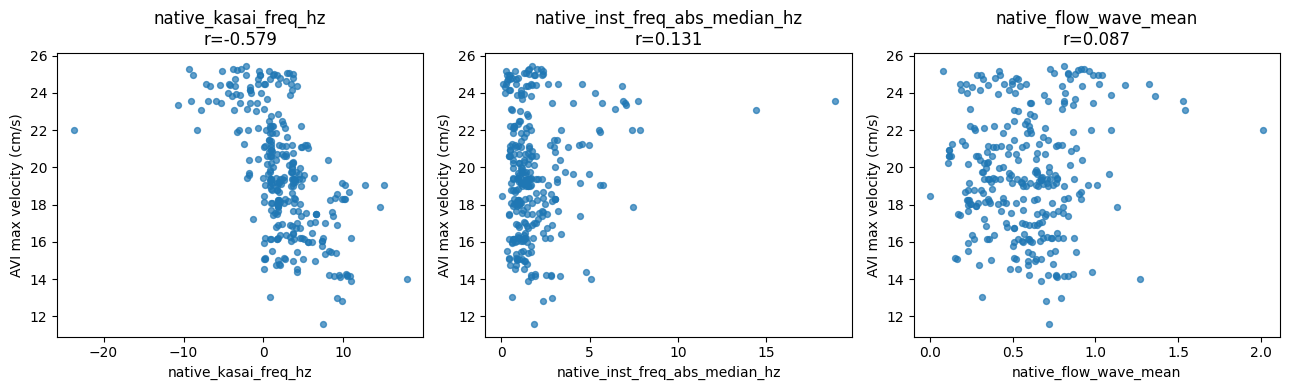

In [24]:
velocity_rows = velocity_df[
    (velocity_df["frame_level_feature_ok"].astype(str) == "True")
    & (velocity_df["image_extraction_ok"].astype(str) == "True")
].copy()

rows = []

for _, match_row in usable_velocity_matches.iterrows():
    native_id = match_row["native_recording_id"]
    avi_name = match_row["matched_recording_name"]

    path = next(path for path in pw_files if recording_id_from_pw_path(path) == native_id)

    t_iq, z = reconstruct_candidate_iq_stream(path)

    phase = np.unwrap(np.angle(z))
    inst_freq_hz = np.diff(phase) * CANDIDATE_IQ_RATE_HZ / (2 * np.pi)
    inst_freq_t = t_iq[1:]

    _, flow_wave, flow_meta = reconstruct_candidate_flow_wave(path)
    flow_t = np.arange(len(flow_wave)) / flow_meta["actual_out_fs_hz"]

    ref = velocity_rows[velocity_rows["recording_name"] == avi_name].copy()

    for _, ref_row in ref.iterrows():
        t = float(ref_row["video_frame_time_s"])

        freq_mask = (inst_freq_t >= t - 0.10) & (inst_freq_t <= t + 0.10)
        z_mask = (t_iq >= t - 0.10) & (t_iq <= t + 0.10)
        flow_mask = (flow_t >= t - 0.10) & (flow_t <= t + 0.10)

        if freq_mask.sum() < 8 or z_mask.sum() < 8 or flow_mask.sum() < 2:
            continue

        z_window = z[z_mask]
        kasai_step = np.angle(np.sum(z_window[1:] * np.conj(z_window[:-1])))
        kasai_freq_hz = kasai_step * CANDIDATE_IQ_RATE_HZ / (2 * np.pi)

        rows.append({
            "native_recording_id": native_id,
            "matched_recording_name": avi_name,
            "video_frame_time_s": t,
            "avi_max_velocity_cm_s": float(ref_row["max_velocity_cm_s"]),

            "native_inst_freq_median_hz": float(np.nanmedian(inst_freq_hz[freq_mask])),
            "native_inst_freq_abs_median_hz": float(np.nanmedian(np.abs(inst_freq_hz[freq_mask]))),
            "native_inst_freq_iqr_hz": float(
                np.nanpercentile(inst_freq_hz[freq_mask], 75)
                - np.nanpercentile(inst_freq_hz[freq_mask], 25)
            ),
            "native_kasai_freq_hz": float(kasai_freq_hz),
            "native_flow_power_mean": float(np.nanmean(flow_wave[flow_mask] ** 2)),
            "native_flow_wave_mean": float(np.nanmean(flow_wave[flow_mask])),
        })

velocity_recovery_audit_df = pd.DataFrame(rows)

metric_cols = [
    "native_inst_freq_median_hz",
    "native_inst_freq_abs_median_hz",
    "native_inst_freq_iqr_hz",
    "native_kasai_freq_hz",
    "native_flow_power_mean",
    "native_flow_wave_mean",
]

corr_rows = []

for metric in metric_cols:
    x = velocity_recovery_audit_df[metric].to_numpy(dtype=float)
    y = velocity_recovery_audit_df["avi_max_velocity_cm_s"].to_numpy(dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)

    if ok.sum() >= 3 and np.nanstd(x[ok]) > 0 and np.nanstd(y[ok]) > 0:
        r = float(np.corrcoef(x[ok], y[ok])[0, 1])
    else:
        r = np.nan

    corr_rows.append({
        "native_metric": metric,
        "n_points": int(ok.sum()),
        "pearson_r_vs_avi_velocity": r,
        "abs_r": abs(r) if np.isfinite(r) else np.nan,
    })

velocity_recovery_corr_df = (
    pd.DataFrame(corr_rows)
    .sort_values("abs_r", ascending=False)
    .reset_index(drop=True)
)

print("Native phase and frequency velocity-recovery audit")
print("==================================================")
print("Matched native recordings:", usable_velocity_matches["native_recording_id"].nunique())
print("Velocity reference rows used:", len(velocity_recovery_audit_df))

display(velocity_recovery_corr_df)

display(
    velocity_recovery_audit_df[
        [
            "native_recording_id",
            "matched_recording_name",
            "video_frame_time_s",
            "avi_max_velocity_cm_s",
            *metric_cols,
        ]
    ].head(20)
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

plot_metrics = [
    "native_kasai_freq_hz",
    "native_inst_freq_abs_median_hz",
    "native_flow_wave_mean",
]

for ax, metric in zip(axes, plot_metrics):
    ax.scatter(
        velocity_recovery_audit_df[metric],
        velocity_recovery_audit_df["avi_max_velocity_cm_s"],
        s=18,
        alpha=0.7,
    )
    r = velocity_recovery_corr_df.loc[
        velocity_recovery_corr_df["native_metric"] == metric,
        "pearson_r_vs_avi_velocity",
    ].iloc[0]
    ax.set_title(f"{metric}\nr={r:.3f}")
    ax.set_xlabel(metric)
    ax.set_ylabel("AVI max velocity (cm/s)")

plt.tight_layout()
plt.show()

### Native phase and frequency velocity-recovery audit interpretation

**Result classification:** mixed global association, not validated velocity recovery.

Evidence-supported observations:

- The strongest global association is `native_kasai_freq_hz` versus AVI-derived `max_velocity_cm_s`, with Pearson `r = -0.58`.
- `native_inst_freq_median_hz` also shows a moderate global association, with Pearson `r = -0.44`.
- Flow-wave amplitude and power metrics show weak global association with AVI-derived velocity.
- The scatter plots show clustered structure rather than a clean continuous calibration relationship.
- A global correlation can be driven by between-recording differences and does not prove within-recording velocity recovery.


## Within-recording velocity-recovery control

### What this tests

This section removes each recording's mean from native-derived metrics and AVI-derived velocity.

It then tests whether native phase/frequency/Kasai-style measures track within-recording velocity changes.

### Why this matters

Global correlation can be caused by recording-level differences.

A native calibrated velocity signal should preserve a relationship with AVI-derived velocity within individual recordings.


Within-recording velocity-recovery control


,native_metric,n_points,within_recording_pearson_r,within_recording_abs_r
0,native_inst_freq_abs_median_hz,300,0.271739,0.271739
1,native_inst_freq_iqr_hz,300,0.254701,0.254701
2,native_kasai_freq_hz,300,-0.215543,0.215543
3,native_inst_freq_median_hz,300,-0.210288,0.210288
4,native_flow_wave_mean,300,0.204864,0.204864
5,native_flow_power_mean,300,0.125314,0.125314


Per-recording correlations


,native_recording_id,native_metric,n_points,per_recording_pearson_r,per_recording_abs_r
0,202606130411060002SMP,native_flow_power_mean,54,0.607595,0.607595
1,202606130426500007SMP,native_flow_power_mean,45,-0.211161,0.211161
2,202606130434130010SMP,native_flow_power_mean,55,0.206587,0.206587
3,202606130433280009SMP,native_flow_power_mean,54,-0.133546,0.133546
4,202606130422440006SMP,native_flow_power_mean,49,-0.055234,0.055234
5,202606130413540003SMP,native_flow_power_mean,43,0.009913,0.009913
6,202606130411060002SMP,native_flow_wave_mean,54,0.641016,0.641016
7,202606130434130010SMP,native_flow_wave_mean,55,0.211545,0.211545
8,202606130426500007SMP,native_flow_wave_mean,45,-0.119694,0.119694
9,202606130422440006SMP,native_flow_wave_mean,49,0.075726,0.075726


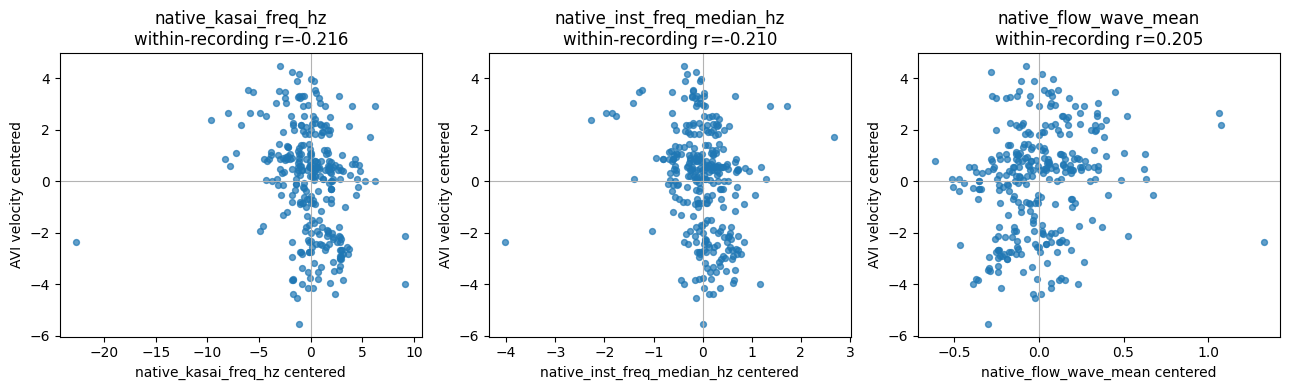

In [25]:
velocity_centered_df = velocity_recovery_audit_df.copy()

for col in ["avi_max_velocity_cm_s", *metric_cols]:
    velocity_centered_df[col + "_centered"] = (
        velocity_centered_df[col]
        - velocity_centered_df.groupby("native_recording_id")[col].transform("mean")
    )

within_corr_rows = []

for metric in metric_cols:
    x = velocity_centered_df[metric + "_centered"].to_numpy(dtype=float)
    y = velocity_centered_df["avi_max_velocity_cm_s_centered"].to_numpy(dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)

    if ok.sum() >= 3 and np.nanstd(x[ok]) > 0 and np.nanstd(y[ok]) > 0:
        r = float(np.corrcoef(x[ok], y[ok])[0, 1])
    else:
        r = np.nan

    within_corr_rows.append({
        "native_metric": metric,
        "n_points": int(ok.sum()),
        "within_recording_pearson_r": r,
        "within_recording_abs_r": abs(r) if np.isfinite(r) else np.nan,
    })

within_velocity_corr_df = (
    pd.DataFrame(within_corr_rows)
    .sort_values("within_recording_abs_r", ascending=False)
    .reset_index(drop=True)
)

per_recording_rows = []

for native_id, group in velocity_recovery_audit_df.groupby("native_recording_id"):
    for metric in metric_cols:
        x = group[metric].to_numpy(dtype=float)
        y = group["avi_max_velocity_cm_s"].to_numpy(dtype=float)
        ok = np.isfinite(x) & np.isfinite(y)

        if ok.sum() >= 5 and np.nanstd(x[ok]) > 0 and np.nanstd(y[ok]) > 0:
            r = float(np.corrcoef(x[ok], y[ok])[0, 1])
        else:
            r = np.nan

        per_recording_rows.append({
            "native_recording_id": native_id,
            "native_metric": metric,
            "n_points": int(ok.sum()),
            "per_recording_pearson_r": r,
            "per_recording_abs_r": abs(r) if np.isfinite(r) else np.nan,
        })

per_recording_velocity_corr_df = pd.DataFrame(per_recording_rows)

print("Within-recording velocity-recovery control")
print("==========================================")
display(within_velocity_corr_df)

print("Per-recording correlations")
print("==========================")
display(
    per_recording_velocity_corr_df
    .sort_values(["native_metric", "per_recording_abs_r"], ascending=[True, False])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

plot_metrics = [
    "native_kasai_freq_hz",
    "native_inst_freq_median_hz",
    "native_flow_wave_mean",
]

for ax, metric in zip(axes, plot_metrics):
    ax.scatter(
        velocity_centered_df[metric + "_centered"],
        velocity_centered_df["avi_max_velocity_cm_s_centered"],
        s=18,
        alpha=0.7,
    )

    r = within_velocity_corr_df.loc[
        within_velocity_corr_df["native_metric"] == metric,
        "within_recording_pearson_r",
    ].iloc[0]

    ax.axhline(0, color="0.7", linewidth=0.8)
    ax.axvline(0, color="0.7", linewidth=0.8)
    ax.set_title(f"{metric}\nwithin-recording r={r:.3f}")
    ax.set_xlabel(metric + " centered")
    ax.set_ylabel("AVI velocity centered")

plt.tight_layout()
plt.show()

## Leave-recording-out velocity calibration control

### What this tests

This section tests whether native-derived phase/frequency metrics can predict AVI-derived velocity in held-out recordings.

A simple linear calibration is fit using all but one native recording, then tested on the held-out recording.

### Why this matters

A calibrated native velocity signal should generalize across recordings.

If prediction does not improve over a simple training-mean baseline, the native metric is not sufficient for calibrated velocity recovery.



In [26]:
rows = []

for metric in metric_cols:
    for heldout_id in sorted(velocity_recovery_audit_df["native_recording_id"].unique()):
        train = velocity_recovery_audit_df[
            velocity_recovery_audit_df["native_recording_id"] != heldout_id
        ].copy()
        test = velocity_recovery_audit_df[
            velocity_recovery_audit_df["native_recording_id"] == heldout_id
        ].copy()

        train = train[np.isfinite(train[metric]) & np.isfinite(train["avi_max_velocity_cm_s"])]
        test = test[np.isfinite(test[metric]) & np.isfinite(test["avi_max_velocity_cm_s"])]

        if len(train) < 5 or len(test) < 5 or train[metric].std() == 0:
            continue

        slope, intercept = np.polyfit(
            train[metric].to_numpy(dtype=float),
            train["avi_max_velocity_cm_s"].to_numpy(dtype=float),
            deg=1,
        )

        y_true = test["avi_max_velocity_cm_s"].to_numpy(dtype=float)
        y_pred = slope * test[metric].to_numpy(dtype=float) + intercept
        y_baseline = np.full_like(y_true, train["avi_max_velocity_cm_s"].mean(), dtype=float)

        mae_model = float(np.mean(np.abs(y_true - y_pred)))
        mae_baseline = float(np.mean(np.abs(y_true - y_baseline)))

        ss_res = float(np.sum((y_true - y_pred) ** 2))
        ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        rows.append({
            "native_metric": metric,
            "heldout_recording_id": heldout_id,
            "n_train": int(len(train)),
            "n_test": int(len(test)),
            "train_slope": float(slope),
            "train_intercept": float(intercept),
            "heldout_mae_cm_s": mae_model,
            "baseline_mae_cm_s": mae_baseline,
            "mae_improvement_cm_s": mae_baseline - mae_model,
            "heldout_r2": float(r2),
        })

velocity_loro_df = pd.DataFrame(rows)

velocity_loro_summary_df = (
    velocity_loro_df
    .groupby("native_metric", as_index=False)
    .agg(
        median_heldout_mae_cm_s=("heldout_mae_cm_s", "median"),
        median_baseline_mae_cm_s=("baseline_mae_cm_s", "median"),
        median_mae_improvement_cm_s=("mae_improvement_cm_s", "median"),
        median_heldout_r2=("heldout_r2", "median"),
        n_holdouts=("heldout_recording_id", "count"),
    )
    .sort_values("median_mae_improvement_cm_s", ascending=False)
)

print("Leave-recording-out velocity calibration control")
print("================================================")
display(velocity_loro_summary_df)

print("Held-out details")
print("================")
display(
    velocity_loro_df
    .sort_values(["native_metric", "heldout_recording_id"])
    .reset_index(drop=True)
)

Leave-recording-out velocity calibration control


,native_metric,median_heldout_mae_cm_s,median_baseline_mae_cm_s,median_mae_improvement_cm_s,median_heldout_r2,n_holdouts
5,native_kasai_freq_hz,2.042007,2.436836,0.514348,-0.308642,6
4,native_inst_freq_median_hz,2.329809,2.436836,0.190809,-0.401861,6
0,native_flow_power_mean,2.323820,2.436836,0.045159,-0.321452,6
1,native_flow_wave_mean,2.407857,2.436836,-0.025785,-0.415089,6
2,native_inst_freq_abs_median_hz,2.813126,2.436836,-0.137932,-1.062179,6
3,native_inst_freq_iqr_hz,3.072084,2.436836,-0.141945,-1.725584,6


Held-out details


,native_metric,heldout_recording_id,n_train,n_test,train_slope,train_intercept,heldout_mae_cm_s,baseline_mae_cm_s,mae_improvement_cm_s,heldout_r2
0,native_flow_power_mean,202606130411060002SMP,246,54,0.679592,18.857610,2.240719,2.422507,0.181788,-0.313695
1,native_flow_power_mean,202606130413540003SMP,257,43,0.975550,18.996774,1.228099,1.189776,-0.038322,-0.086070
2,native_flow_power_mean,202606130422440006SMP,251,49,1.575773,19.286606,4.583752,4.155349,-0.428402,-6.298412
3,native_flow_power_mean,202606130426500007SMP,255,45,0.220602,18.647998,5.508804,5.604165,0.095361,-26.652348
4,native_flow_power_mean,202606130433280009SMP,246,54,0.940771,19.188561,1.836354,1.882428,0.046073,-0.329210
5,native_flow_power_mean,202606130434130010SMP,245,55,0.831423,19.175818,2.406920,2.451164,0.044244,-0.036268
6,native_flow_wave_mean,202606130411060002SMP,246,54,0.268316,19.177155,2.387075,2.422507,0.035432,-0.430211
7,native_flow_wave_mean,202606130413540003SMP,257,43,1.049513,19.069987,1.216504,1.189776,-0.026728,-0.100260
8,native_flow_wave_mean,202606130422440006SMP,251,49,2.800947,18.767722,4.694164,4.155349,-0.538815,-6.538714
9,native_flow_wave_mean,202606130426500007SMP,255,45,-0.191926,18.893797,5.629009,5.604165,-0.024843,-27.673817


### Leave-recording-out velocity calibration control interpretation

**Result classification:** calibrated velocity recovery not supported.

Evidence-supported observations:

- Leave-recording-out calibration does not produce reliable held-out velocity prediction.
- Most native metrics have negative median held-out `R²`, meaning they perform worse than a simple training-mean baseline.
- `native_kasai_freq_hz` has the best median MAE improvement, but median held-out `R²` remains negative.
- The apparent benefit of `native_kasai_freq_hz` is inconsistent across held-out recordings.
- Several held-out recordings show poor or very poor generalization, including large negative `R²`.
- Flow-wave amplitude and power metrics do not provide reliable held-out calibrated velocity prediction.
- The phase-frequency spread metrics perform worse than baseline by median MAE.


## Final checkpoint - Native PW flow-wave and velocity boundary

**Result classification:** native timing/pulsatility supported; calibrated velocity recovery not supported.

### Supported findings

- `PW_CinePartition0.bin` is a fixed-page native PW stream with `1296` byte pages.
- The working native page-rate assumption is `500 Hz`.
- Records `0..15` are the main live finite `float32` value records.
- Records `144` and `154` show control/status-like variability and are not part of the main PW value payload.
- Records `0..13` support a structurally plausible adjacent-pair stream: `(0,1),(2,3),...,(12,13)`.
- The adjacent-pair stream gives `7` candidate samples per page, or `3500 Hz`.
- Adjacent-pair ordering has stronger continuity than split-half or reversed-within-page controls.
- A wall-filtered flow-power waveform can be reproduced directly from raw bytes.
- The true reproduced flow-wave sample rate is `3500 / 17 = 205.882352941 Hz`.
- Recomputed flow-wave HR agrees with AVI-audio HR within `5 bpm` in 9 of 10 recordings and within `10 bpm` in all 10 recordings.
- Stricter peak selection shows plausible candidate cycle markers in selected recordings, but final beat segmentation is not validated.

### Velocity recovery findings

- Native phase/frequency/Kasai-style metrics show some global association with AVI-derived velocity.
- Within-recording correlations are weak overall and inconsistent across recordings.
- One recording shows stronger within-recording phase/frequency association, but this does not generalize.
- Leave-recording-out calibration does not provide reliable held-out velocity prediction.
- Most tested native metrics perform worse than a simple training-mean baseline by held-out `R²`.
- Flow-wave amplitude and power do not provide calibrated velocity recovery.

### Supported uses

The native-derived flow-wave is supported as:

- an experimental timing signal,
- an experimental pulsatility-like signal,
- a heart-rate / QC support signal,
- a candidate cycle-segmentation input requiring additional validation.
